# Predicted-GR cascade (gain-prior WS E2E) — Local Eval

Evaluates models trained by [`train_lstm_gain_prior_ws_e2e.ipynb`](train_lstm_gain_prior_ws_e2e.ipynb)
(`GainPriorWSE2ELSTM`): the oracle gain-prior waveshaper architecture, but trained
on the **frozen blackbox GR predictor's** output instead of the oracle curve —
the fully causal cascade:

```
dry x ── frozen BlackboxGRLSTM(x, knobs) ──► ĝr (predicted, dB)
dry x, ĝr, knobs ── GainPriorWSE2ELSTM ──► y
```

**Every number in this notebook is deployable** — the GR fed to the model is
regenerated locally by the exact predictor run + checkpoint recorded in the
run's `hparams.json` (`gr_frontend`), streamed full-song with carried state
(cold start only at the true song start — the training condition). No wet
audio touches the model input anywhere, so these numbers are honestly
comparable to the black-box SOTA (`LSTM32TVC`), unlike the oracle-GR evals.

The metric engine, streaming and layout are **byte-identical** to
[`06_output/eval_lstm_gain_prior_ws.ipynb`](../06_output/eval_lstm_gain_prior_ws.ipynb)
(the oracle eval), so the 9-column numbers drop straight into the cross-model
comparison; the oracle run's tables are the upper bound, and the gap is the
price of predicting GR. What changes here:

- **Stage-1 setup cells (5c/5d/5e)**: load the frozen predictor, regenerate +
  cache the predicted curves (once, next to the predictor run, keyed by
  checkpoint), and score them against the oracle curves.
- **All GR inputs** come from the predicted cache; the oracle curve appears
  only as a reference line in plots and as an ablation variant.
- **Ablation section 9 is flipped**: `predicted` is now the *native* row (==
  the split metrics), and `oracle` is the counterfactual — how much better the
  trained cascade gets with a perfect prior, i.e. the residual cost of
  predictor error that the learned Δg could not correct.


In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────

import gc, glob, json, os, sys, types, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore", category=UserWarning)

# model_gainprior_ws_e2e -> model_gainprior_ws -> model_tfilm imports nablafx's
# TVFiLMCond. Stub the `rational` / `frechet_audio_distance` import-chain deps
# so `from nablafx...` doesn't drag in broken wheels — identical to the train
# notebook's cell 0.
_rational = types.ModuleType("rational")
_rational.torch = types.ModuleType("rational.torch")
_rational.torch.Rational = type("Rational", (), {})
sys.modules.setdefault("rational", _rational)
sys.modules.setdefault("rational.torch", _rational.torch)
_fad = types.ModuleType("frechet_audio_distance")
_fad.FrechetAudioDistance = type("FrechetAudioDistance", (), {})
sys.modules.setdefault("frechet_audio_distance", _fad)

REPO_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "pyproject.toml").is_file()),
    Path.cwd().resolve(),
)
sys.path.insert(0, str(REPO_ROOT))                       # `src`
sys.path.insert(0, str(REPO_ROOT / "nablafx"))           # raw ./nablafx/ clone (TVFiLMCond)
sys.path.insert(0, str(REPO_ROOT / "06_output"))         # model base, amplitude_match, splits
sys.path.insert(0, str(REPO_ROOT / "03_initial_GR_pred"))  # eval_helpers
sys.path.insert(0, str(REPO_ROOT / "09_end2end"))        # model_gainprior_ws_e2e, gr_frontend
# NOTE: 05_conditioning stays OFF sys.path (its splits.py/model.py collide with
# 06_output); gr_frontend loads its modules by explicit file path.

from amplitude_match import GR_DB_MIN, GR_DB_MAX, amplitude_match
from model_gainprior_ws_e2e import GainPriorWSE2ELSTM
from gr_frontend import load_frozen_gr_predictor, predict_gr_view
from dataset_tfilm import discover_gr_pairs
from splits import SplitManifest, normalize_setting_params
from system_gainprior import esr_metric
from eval_helpers import (
    _checkpoint_sort_key, _find_hparams_json, _pair_num_frames,
    _read_dry_wet_segment, _weighted_average_metric_rows, latest_best_checkpoint,
    list_runs, plot_loss_curves,
)
from src.dsp_torch import RMS_WINDOW, gain_reduction_db

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/diffssl_e2e_runs"
GR_PRED_RUNS = "/Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs"
DEVICE = "cpu"

print(f"torch {torch.__version__}  |  device: {DEVICE}")
print(f"GR clamp: [{GR_DB_MIN}, {GR_DB_MAX}] dB  |  RMS window: {RMS_WINDOW} samples")


/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0  |  device: cpu
GR clamp: [-30.0, 5.0] dB  |  RMS window: 1024 samples


In [2]:
# ── 1. List available e2e (predicted-GR cascade) runs ────────────────

MODEL_TYPE = "GainPriorWSE2ELSTM"   # hparams["model_type"]

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, f"No runs in {RUNS_DIR}"
available_models_df = runs_df[runs_df["type"] == MODEL_TYPE].copy()
if available_models_df.empty:
    # fall back to folder-name tag if hparams["model_type"] is missing/older
    available_models_df = runs_df[runs_df["run"].str.contains("predgr", case=False, na=False)].copy()
assert not available_models_df.empty, (
    f"No '{MODEL_TYPE}' runs in {RUNS_DIR} — train with train_lstm_gain_prior_ws_e2e.ipynb first."
)

display_cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available predicted-GR cascade runs: {len(available_models_df)}")
display(available_models_df[display_cols])


Available predicted-GR cascade runs: 1


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
0,e2e_predgr_20260705_185738_diffssl_lstm32_ws_p...,GainPriorWSE2ELSTM,100,0.104097,4,best-086-1305000.ckpt,2026-07-06 00:26:26.935922146


In [3]:
# ── 2. Select run, checkpoint and split manifest ─────────────────────

# Leave as None to auto-pick the most recently modified matching run.
SELECTED_RUN_NAME: str | None = "e2e_predgr_20260705_185738_diffssl_lstm32_ws_predgr"

if not SELECTED_RUN_NAME:
    selected_run = available_models_df.iloc[-1]   # list_runs sorts by mtime asc
else:
    matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
    assert len(matches) == 1, f"Run not found: {SELECTED_RUN_NAME}"
    selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

with open(HPARAMS_PATH) as f:
    HP = json.load(f)
SPLIT = SplitManifest.load(os.path.join(RUN_DIR, "split_manifest.json"))


def _pairs_from_keys(keys) -> list[tuple[str, str]]:
    return [tuple(k.split("::")) for k in sorted(keys)]   # (song, setting)


VAL_PAIRS = _pairs_from_keys(SPLIT.val_pair_keys)
TEST_PAIRS = _pairs_from_keys(SPLIT.test_pair_keys)

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")
print(f"Matched input  : {HP.get('use_matched_input', True)}")
print(f"GR frontend    : {HP['gr_frontend']['run']} / {HP['gr_frontend']['ckpt']} "
      f"({HP['gr_frontend']['num_params']:,} params, frozen)")
print(f"Val pairs      : {len(VAL_PAIRS)}  ({SPLIT.val_songs} x all settings)")
print(f"Test pairs     : {len(TEST_PAIRS)}  (external test_ground_truth — unseen by BOTH stages)")


Selected run   : e2e_predgr_20260705_185738_diffssl_lstm32_ws_predgr
Eval checkpoint: best-086-1305000.ckpt
Best val loss  : 0.104097
Matched input  : True
GR frontend    : lstm_gr_20260705_125142_lstm_blackbox_gr_film / best-081-41000.ckpt (16,249 params, frozen)
Val pairs      : 10  (['AncoraQui'] x all settings)
Test pairs     : 5  (external test_ground_truth — unseen by BOTH stages)


In [4]:
# ── 3. Inspect checkpoints ──────────────────────────────────────────

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(CKPT_DIR, "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    sz = os.path.getsize(c) / 1e6
    print(f"  {os.path.basename(c):<36}  {sz:6.2f} MB{marker}")

Selected run   : e2e_predgr_20260705_185738_diffssl_lstm32_ws_predgr
Eval checkpoint: best-086-1305000.ckpt
Checkpoints    :
  last.ckpt                               0.13 MB
  best-076-1155000.ckpt                   0.13 MB
  best-084-1275000.ckpt                   0.13 MB
  best-086-1305000.ckpt                   0.13 MB <-- eval


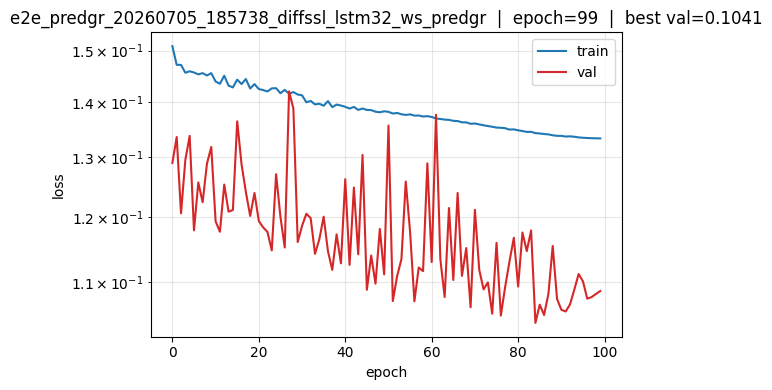

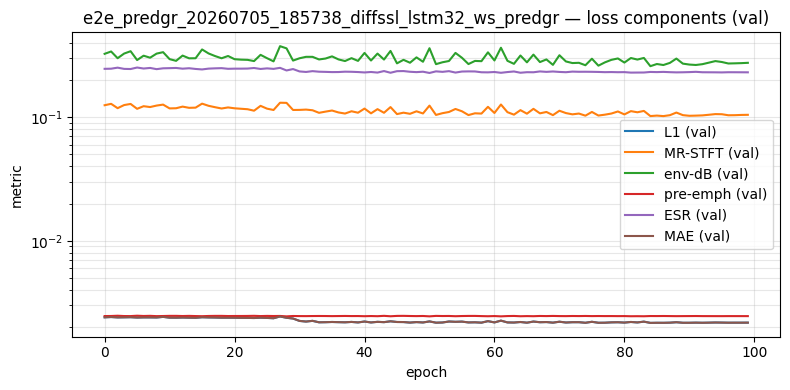

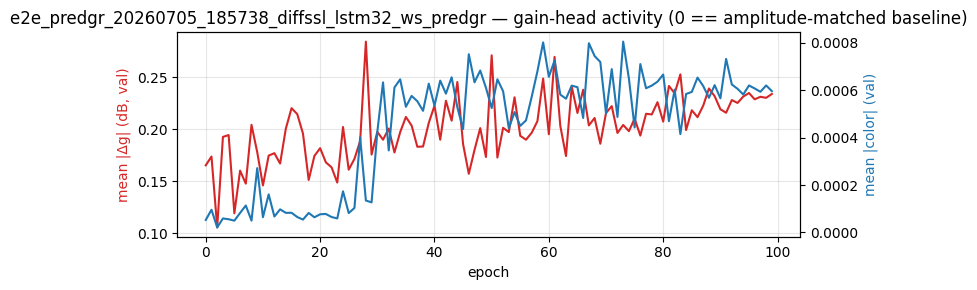

In [5]:
# ── 4. Loss curves (total + components + gain-head activity) ─────────

_ = plot_loss_curves(RUN_DIR)

csv_path = Path(RUN_DIR) / "csv" / "metrics.csv"
if csv_path.exists():
    _df = pd.read_csv(csv_path)

    comp_cols = [
        ("loss/val_td", "L1 (val)"),
        ("loss/val_fd", "MR-STFT (val)"),
        ("loss/val_env", "env-dB (val)"),
        ("loss/val_pe", "pre-emph (val)"),
        ("esr/val", "ESR (val)"),
        ("mae/val", "MAE (val)"),
    ]
    if any(c in _df.columns for c, _ in comp_cols):
        fig, ax = plt.subplots(figsize=(8, 4))
        for col, label in comp_cols:
            if col in _df.columns:
                rows = _df.dropna(subset=[col])[["epoch", col]]
                if len(rows):
                    ax.plot(rows["epoch"], rows[col], label=label, lw=1.5)
        ax.set_xlabel("epoch"); ax.set_ylabel("metric"); ax.set_yscale("log")
        ax.grid(alpha=0.3, which="both"); ax.legend()
        ax.set_title(f"{RUN_NAME} — loss components (val)")
        plt.tight_layout(); plt.show()

    # gain-head activity: how far the model moves off the amplitude-matched
    # baseline (both start at exactly 0 by construction).
    gain_cols = [("gain/val_delta_db", "mean |Δg| (dB, val)"),
                 ("gain/val_color", "mean |color| (val)")]
    if any(c in _df.columns for c, _ in gain_cols):
        fig, ax = plt.subplots(figsize=(8, 3))
        ax2 = ax.twinx()
        for (col, label), a, color in zip(gain_cols, (ax, ax2), ("#d62728", "#1f77b4")):
            if col in _df.columns:
                rows = _df.dropna(subset=[col])[["epoch", col]]
                if len(rows):
                    a.plot(rows["epoch"], rows[col], label=label, lw=1.5, color=color)
                    a.set_ylabel(label, color=color)
        ax.set_xlabel("epoch"); ax.grid(alpha=0.3)
        ax.set_title(f"{RUN_NAME} — gain-head activity (0 == amplitude-matched baseline)")
        plt.tight_layout(); plt.show()

In [6]:
# ── 5. Checkpoint loading (GainPriorWSE2ELSTM) ───────────────────────

def load_model_from_ckpt(ckpt_path, hparams_path=None):
    # Build from hparams.json and load weights (strip Lightning 'model.' prefix).
    hparams_path = hparams_path or _find_hparams_json(ckpt_path)
    with open(hparams_path) as f:
        hp = json.load(f)
    assert hp.get("model_type") == MODEL_TYPE, hp.get("model_type")
    m = hp["model"]
    model = GainPriorWSE2ELSTM(
        use_matched_input=bool(m.get("use_matched_input", True)),
        num_controls=int(m["num_controls"]),
        hidden_size=int(m["hidden_size"]),
        num_layers=int(m["num_layers"]),
        tvcond_dim=int(m.get("tvcond_dim", 16)),
        cond_block_size=int(m.get("cond_block_size", 128)),
        cond_num_layers=int(m.get("cond_num_layers", 1)),
        delta_max_db=float(m.get("delta_max_db", 12.0)),
        use_color=bool(m.get("use_color", True)),
        ws_hidden=int(m.get("ws_hidden", 8)),
        ws_film=bool(m.get("ws_film", False)),
    )
    sd = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)["state_dict"]
    model.load_state_dict({k[len("model."):]: v for k, v in sd.items() if k.startswith("model.")})
    model.to(DEVICE).eval()
    n_params = sum(p.numel() for p in model.parameters())
    print(
        f"Loaded {n_params:,}-param GainPriorWSE2ELSTM  "
        f"(hidden={model.hidden_size}, controls={model.num_controls}, "
        f"matched_input={model.use_matched_input}, cond_block={model.cond_block_size}, "
        f"delta_max={model.delta_max_db} dB, color={model.use_color}, ws_film={model.ws_film})"
    )
    return model, hp


MODEL, HP = load_model_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
SR = int(HP["sample_rate"])
SAMPLE_LENGTH = int(HP.get("sample_length", 132300))
# GR derived from waveforms uses the same 1024-sample causal RMS window the
# exported gr_curves were built with (matches eval_lstm_condlstm_gr_bins.ipynb).
RMS_WIN = int(HP.get("rms_window", RMS_WINDOW))


Loaded 8,418-param GainPriorWSE2ELSTM  (hidden=32, controls=4, matched_input=True, cond_block=128, delta_max=12.0 dB, color=True, ws_film=False)


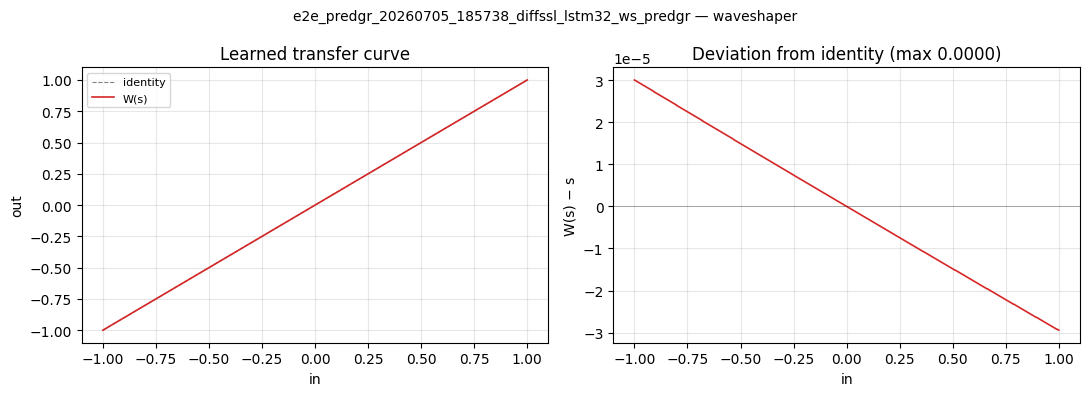

In [7]:
# ── 5b. Learned transfer curve W(s) — the coloration mechanism ───────
# The waveshaper is where harmonics come from (composition, not additive
# synthesis): plot W(s) vs identity and the deviation W(s)−s. Bowing away from
# identity at high |s| = saturation; asymmetry = even harmonics. With ws_film
# on, the curve is programme-modulated — this is the UNMODULATED static curve.

_s = torch.linspace(-1.0, 1.0, 1001, device=DEVICE).view(1, 1, -1)
with torch.no_grad():
    _w = MODEL.waveshaper(_s).cpu().flatten().numpy()
_s = _s.cpu().flatten().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(_s, _s, "--", color="gray", lw=0.8, label="identity")
ax1.plot(_s, _w, color="#d62728", lw=1.2, label="W(s)")
ax1.set_xlabel("in"); ax1.set_ylabel("out"); ax1.set_title("Learned transfer curve")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax2.plot(_s, _w - _s, color="#d62728", lw=1.2)
ax2.axhline(0, color="k", lw=0.5, alpha=0.4)
ax2.set_xlabel("in"); ax2.set_ylabel("W(s) − s")
ax2.set_title(f"Deviation from identity (max {np.abs(_w - _s).max():.4f})")
ax2.grid(alpha=0.3)
fig.suptitle(f"{RUN_NAME} — waveshaper", fontsize=10)
plt.tight_layout(); plt.show()


In [8]:
# ── 5c. Stage 1: the frozen blackbox GR predictor recorded in hparams ──
# The run's hparams pin the exact predictor run AND checkpoint that generated
# the training curves; eval must regenerate GR with the same pair, otherwise
# the model is fed a curve distribution it was never trained on.

GRF = HP["gr_frontend"]
GR_RUN_DIR = os.path.join(GR_PRED_RUNS, GRF["run"])
GR_CKPT = os.path.join(GR_RUN_DIR, "checkpoints", GRF["ckpt"])
assert os.path.isfile(GR_CKPT), f"Frontend checkpoint not synced locally: {GR_CKPT}"

GR_MODEL, GR_HP, GR_CKPT_PATH = load_frozen_gr_predictor(
    GR_RUN_DIR, str(REPO_ROOT / "05_conditioning"), ckpt_path=GR_CKPT, device=DEVICE)

# cross-stage split guard — same assert as the training notebook: the test
# pairs must be unseen by BOTH stages.
assert set(GR_HP["test_pair_keys"]) == set(SPLIT.test_pair_keys), (
    "GR predictor was trained under a DIFFERENT test split than this run")
assert int(GR_HP["sample_rate"]) == SR and int(GR_HP["split_seed"]) == int(HP["split_seed"])
print(f"Split guard OK ({len(TEST_PAIRS)} test pairs)")
print(f"Training-time predictor MAE vs oracle (post-1s): {GRF['pred_mae_vs_oracle_db']}")


Frozen GR predictor: 16,249 params  (blackbox_gr_lstm_film)
  ckpt: best-081-41000.ckpt
Split guard OK (5 test pairs)
Training-time predictor MAE vs oracle (post-1s): {'test_mae_db_post1s': 0.3676, 'train/val_mae_db_post1s': 0.2959}


In [9]:
# ── 5d. Predicted-GR curves — regenerate locally, cache once ──────────
# Same exporter as the training notebook (gr_frontend.predict_gr_view):
# full-song streaming with state carried across hop-aligned 120 s chunks,
# per-song batching over settings, one interpolation to sample rate — cold
# start only at the true song start. Curves are cached NEXT TO THE PREDICTOR
# RUN keyed by checkpoint stem, so they are computed once and shared across
# eval sessions (and across any e2e run trained on the same frontend).
# First run predicts the 15 val+test pairs on CPU — expect a few minutes.

VIEW_ROOT = os.path.join(GR_RUN_DIR, f"pred_gr_view_{Path(GR_CKPT_PATH).stem}")
_ALL_PAIRS = {(p["song"], p["setting"]): p
              for p in discover_gr_pairs(DATA_ROOT, include_test_ground_truth=True)}


def _pred_gr_path(song: str, setting: str) -> str:
    return os.path.join(VIEW_ROOT, "gr_curves", setting, f"{song}.pt")


@torch.no_grad()
def ensure_predicted_gr(pair_list):
    # pair_list: iterable of (song, setting); predicts + caches the missing ones.
    keys = list(dict.fromkeys((song, setting) for song, setting in pair_list))
    todo = [_ALL_PAIRS[k] for k in keys if not os.path.isfile(_pred_gr_path(*k))]
    if not todo:
        return None
    print(f"Predicting GR for {len(todo)} pairs -> {VIEW_ROOT} (one-time, cached)")
    return predict_gr_view(GR_MODEL, todo, VIEW_ROOT, DATA_ROOT, device=DEVICE,
                           test_keys=set(SPLIT.test_pair_keys))


def predicted_gr_full(song: str, setting: str) -> torch.Tensor:
    # [1, T] dB — the deployable prior (dry + knobs only, streamed full-song).
    if not os.path.isfile(_pred_gr_path(song, setting)):
        ensure_predicted_gr([(song, setting)])
    gr = torch.load(_pred_gr_path(song, setting), map_location="cpu",
                    weights_only=False)["gr_db"].float()
    return gr.unsqueeze(0) if gr.dim() == 1 else gr


def oracle_gr_full(song: str, setting: str) -> torch.Tensor:
    # [1, T] dB — the oracle export (from wet); plots + ablation only.
    gr = torch.load(os.path.join(DATA_ROOT, "gr_curves", setting, f"{song}.pt"),
                    map_location="cpu", weights_only=False)["gr_db"].float()
    return gr.unsqueeze(0) if gr.dim() == 1 else gr


_ = ensure_predicted_gr(VAL_PAIRS + TEST_PAIRS)
print(f"Predicted-GR cache ready: {VIEW_ROOT}")


Predicted-GR cache ready: /Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs/lstm_gr_20260705_125142_lstm_blackbox_gr_film/pred_gr_view_best-081-41000


,GR MAE (dB),GR MAE post-1s (dB)
Split,,
test,0.374,0.368
validation,0.322,0.322


,Split,Song,Setting,GR MAE (dB),GR MAE post-1s (dB),Minutes
0,validation,AncoraQui,threshold_-12_attack_10_release_0.4_ratio_10,0.589864,0.589151,3.890890
1,validation,AncoraQui,threshold_-12_attack_1_release_0.1_ratio_2,0.485207,0.483935,3.890890
2,validation,AncoraQui,threshold_-4_attack_10_release_0.1_ratio_2,0.264757,0.265104,3.890890
3,validation,AncoraQui,threshold_-4_attack_1_release_0.4_ratio_10,0.662420,0.663991,3.890890
4,validation,AncoraQui,threshold_-8_attack_30_release_0.8_ratio_4,0.376423,0.375309,3.890890
5,validation,AncoraQui,threshold_0_attack_3_release_0.8_ratio_4,0.412049,0.412132,3.890890
6,validation,AncoraQui,threshold_12_attack_3_release_0.8_ratio_2,0.126976,0.126997,3.890890
7,validation,AncoraQui,threshold_4_attack_10_release_0.1_ratio_10,0.108575,0.108488,3.890890
8,validation,AncoraQui,threshold_8_attack_1_release_0.1_ratio_10,0.093062,0.093132,3.890890
9,validation,AncoraQui,threshold_8_attack_30_release_0.4_ratio_2,0.099641,0.099871,3.890890


Training-time quality (gr_pred_quality.csv, test rows) — should match:


,song,setting,split,mae_db,mae_db_post1s,minutes
0,54,threshold_12_attack_1_release_0.1_ratio_2,test,0.102,0.097,4.143
1,Convertible,threshold_4_attack_30_release_0.8_ratio_10,test,0.141,0.141,3.415
2,IncidenteEnIntag,threshold_-12_attack_1_release_0.8_ratio_2,test,0.620,0.605,3.053
3,OralHygiene,threshold_-8_attack_3_release_0.4_ratio_4,test,0.731,0.722,3.392
4,SuchFinePeople,threshold_4_attack_1_release_0.8_ratio_10,test,0.276,0.273,3.671


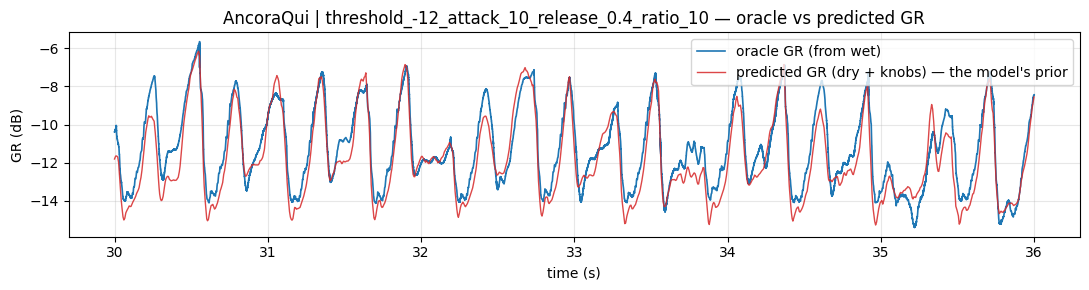

In [10]:
# ── 5e. Predictor quality on the eval pairs (vs the oracle curves) ────
# The cascade inherits this error — it is the floor on what stage 2 must
# correct through Δg. Recomputed from the cached curves; the test rows should
# reproduce the training notebook's gr_pred_quality.csv (saved in RUN_DIR).

def _gr_quality_row(song, setting, split):
    pred, orc = predicted_gr_full(song, setting), oracle_gr_full(song, setting)
    n = min(pred.shape[-1], orc.shape[-1])
    err = (pred[..., :n] - orc[..., :n]).abs()
    return {"Split": split, "Song": song, "Setting": setting,
            "GR MAE (dB)": float(err.mean()),
            "GR MAE post-1s (dB)": float(err[..., SR:].mean()) if n > SR else float("nan"),
            "Minutes": n / SR / 60.0}


gr_quality_df = pd.DataFrame(
    [_gr_quality_row(song, setting, "validation") for song, setting in VAL_PAIRS]
    + [_gr_quality_row(song, setting, "test") for song, setting in TEST_PAIRS]
)
display(gr_quality_df.groupby("Split")[["GR MAE (dB)", "GR MAE post-1s (dB)"]].mean().round(3))
display(gr_quality_df)

_train_csv = os.path.join(RUN_DIR, "gr_pred_quality.csv")
if os.path.isfile(_train_csv):
    _tq = pd.read_csv(_train_csv)
    print("Training-time quality (gr_pred_quality.csv, test rows) — should match:")
    display(_tq[_tq["split"] == "test"].round(3))

# overlay: oracle vs predicted GR — first val pair, 6 s @ 30 s
_song, _setting = VAL_PAIRS[0]
_a, _b = int(30 * SR), int(36 * SR)
_p, _o = predicted_gr_full(_song, _setting), oracle_gr_full(_song, _setting)
_t = np.arange(_a, _b) / SR
plt.figure(figsize=(11, 3))
plt.plot(_t, _o[0, _a:_b].numpy(), lw=1.2, label="oracle GR (from wet)", color="#1f77b4")
plt.plot(_t, _p[0, _a:_b].numpy(), lw=1.0, label="predicted GR (dry + knobs) — the model's prior",
         color="#d62728", alpha=0.85)
plt.xlabel("time (s)"); plt.ylabel("GR (dB)"); plt.grid(alpha=0.3); plt.legend()
plt.title(f"{_song} | {_setting} — oracle vs predicted GR")
plt.tight_layout(); plt.show()


In [11]:
# ── 6. Prediction & visualisation (stateful, predicted-GR cascade) ────
# The model takes the RAW dry signal, the 4 static knobs (from the setting
# name), and the PREDICTED sample-aligned GR curve (sliced out of the cached
# full-song prediction — slicing preserves the deployment condition because
# the curve was streamed with the only cold start at the true song start).
# A `pre_roll_sec` context is fed first (after reset_states) to warm the
# internal LSTM states, then the segment is cropped out.
#
# Besides the waveform we recover a gain-reduction curve from the prediction
# (GR_pred = RMS_dB(pred) − RMS_dB(dry)) AND expose the model's own
# decomposition via return_parts_full: Δg (dB — with a predicted prior this is
# the predictor-ERROR correction, the new work unit of this model), the
# waveshaper residual W(s)−s and the additive coloration c. The oracle curve
# is loaded alongside purely for the plots.

DEFAULT_PRE_ROLL_SEC = 10.0


def pair_paths(setting: str, song: str) -> tuple[str, str]:
    # dry + wet only — the GR input comes from predicted_gr_full. Wet resolves
    # from processed_ground_truth, falling back to test_ground_truth (the v2
    # external test pairs), so ONE streaming path serves both splits.
    dry = os.path.join(DATA_ROOT, "processed_normalized", f"{song}_UnmasteredWAV.wav")
    for d in ("processed_ground_truth", "test_ground_truth"):
        wet = os.path.join(DATA_ROOT, d, setting, f"{song}-exported.wav")
        if os.path.isfile(wet):
            return dry, wet
    raise FileNotFoundError(f"No wet audio for {song} / {setting}")


def _params_for(setting: str) -> torch.Tensor:
    # Normalised static knobs [1, num_controls] from the setting folder name.
    return torch.tensor(normalize_setting_params(setting), dtype=torch.float32,
                        device=DEVICE).unsqueeze(0)


def _gr_from_audio(dry: torch.Tensor, sig: torch.Tensor) -> np.ndarray:
    # Gain reduction (dB) of `sig` relative to `dry`, clamped to the GR range.
    return (
        gain_reduction_db(dry, sig, RMS_WIN).clamp(GR_DB_MIN, GR_DB_MAX).squeeze().cpu().numpy()
    )


@torch.no_grad()
def predict_wet_segment(setting, song, start_sec=0.0, duration_sec=6.0,
                        pre_roll_sec=DEFAULT_PRE_ROLL_SEC, model=None):
    model = model or MODEL
    sr = SR
    dry_path, wet_path = pair_paths(setting, song)

    start = int(round(start_sec * sr))
    stop = start + int(round(duration_sec * sr))
    context_start = max(0, start - int(round(pre_roll_sec * sr)))
    offset = start - context_start   # warm-up length

    dry_ctx, wet_ctx = _read_dry_wet_segment(dry_path, wet_path, context_start, stop, sr)
    gr_ctx = predicted_gr_full(song, setting)[..., context_start:stop]
    orc_ctx = oracle_gr_full(song, setting)[..., context_start:stop]
    n = min(dry_ctx.shape[-1], gr_ctx.shape[-1], wet_ctx.shape[-1], orc_ctx.shape[-1])
    dry_ctx, gr_ctx = dry_ctx[..., :n], gr_ctx[..., :n]
    wet_ctx, orc_ctx = wet_ctx[..., :n], orc_ctx[..., :n]
    params = _params_for(setting)

    model.reset_states()
    pred_full, delta_full, color_full, ws_full = model(
        dry_ctx.unsqueeze(0).to(DEVICE), gr_ctx.unsqueeze(0).to(DEVICE), params,
        return_parts_full=True)

    seg_len = min(stop - start, pred_full.shape[-1] - offset)
    sl = slice(offset, offset + seg_len)
    pred = pred_full[..., sl].squeeze(0).cpu()
    delta = delta_full[..., sl].squeeze(0).cpu()
    color = color_full[..., sl].squeeze(0).cpu()
    ws = ws_full[..., sl].squeeze(0).cpu()
    wet = wet_ctx[..., sl].cpu()
    dry = dry_ctx[..., sl].cpu()
    gr_in = gr_ctx[..., sl].cpu()
    gr_orc = orc_ctx[..., sl].cpu()
    err = (pred - wet).squeeze().numpy()

    # Recover GR curves from the waveforms (same definition as the GR-bins model).
    gr_true = _gr_from_audio(dry, wet)
    gr_pred = _gr_from_audio(dry, pred)
    gr_err = gr_pred - gr_true

    # predictor error on this segment (both clamped to the GR range)
    gr_in_err = (gr_in.clamp(GR_DB_MIN, GR_DB_MAX)
                 - gr_orc.clamp(GR_DB_MIN, GR_DB_MAX)).squeeze().numpy()

    t_len = pred.shape[-1]
    return {
        "song": song, "setting": setting,
        "sample_rate": sr, "start_sec": start_sec, "duration_sec": t_len / sr,
        "pre_roll_sec": offset / sr, "time": np.arange(t_len) / sr,
        "dry": dry.squeeze().numpy(),
        "wet": wet.squeeze().numpy(), "pred": pred.squeeze().numpy(),
        "error": err,
        "gr_in": gr_in.squeeze().numpy(),
        "gr_oracle": gr_orc.squeeze().numpy(),
        "delta_db": delta.squeeze().numpy(), "color": color.squeeze().numpy(),
        "ws_res": ws.squeeze().numpy(),
        "gr_true": gr_true, "gr_pred": gr_pred, "gr_error": gr_err,
        "mae": float(np.mean(np.abs(err))),
        "esr": float(esr_metric(wet.unsqueeze(0), pred.unsqueeze(0))),
        "gr_mae_db": float(np.mean(np.abs(gr_err))),
        "gr_rmse_db": float(np.sqrt(np.mean(gr_err ** 2))),
        "gr_in_mae_db": float(np.mean(np.abs(gr_in_err))),
        "delta_mae_db": float(np.mean(np.abs(delta.numpy()))),
        "color_mae": float(np.mean(np.abs(color.numpy()))),
        "ws_mae": float(np.mean(np.abs(ws.numpy()))),
    }


def visualize_prediction(setting=None, song=None, start_sec=30.0, duration_sec=6.0,
                         pre_roll_sec=DEFAULT_PRE_ROLL_SEC, title=None):
    song = song or TEST_PAIRS[0][0]
    setting = setting or TEST_PAIRS[0][1]
    seg = predict_wet_segment(setting, song, start_sec, duration_sec, pre_roll_sec)

    t = seg["time"]
    # rows: dry | waveform (wet/pred) | waveform error + waveshaper residual
    #       | GR (true/pred) | GR err | gain decomposition (ĝr vs ĝr+Δg vs oracle)
    fig, axes = plt.subplots(6, 1, figsize=(11, 15.5), sharex=True,
                             gridspec_kw={"height_ratios": [1, 2, 1, 2, 1, 2]})

    axes[0].plot(t, seg["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry"); axes[0].set_ylim(-1.05, 1.05); axes[0].grid(alpha=0.3)

    axes[1].plot(t, seg["wet"], label="target (wet)", lw=1.0, color="#1f77b4")
    axes[1].plot(t, seg["pred"], label="prediction", lw=0.9, color="#d62728", alpha=0.85)
    axes[1].set_ylabel("amp"); axes[1].legend(loc="lower right"); axes[1].set_ylim(-1.05, 1.05)
    axes[1].grid(alpha=0.3)

    # waveform error, with the waveshaper residual W(s)−s overlaid (the coloration
    # the transfer curve injects — should track onsets / high-|s| samples).
    axes[2].plot(t, seg["error"], lw=0.8, color="#2ca02c", label="wave err")
    axes[2].plot(t, seg["ws_res"], lw=0.7, color="#d62728", alpha=0.6, label="W(s)−s")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("wave err"); axes[2].legend(loc="lower right", fontsize=8)
    axes[2].grid(alpha=0.3)

    axes[3].plot(t, seg["gr_true"], label="target", lw=1.4, color="#1f77b4")
    axes[3].plot(t, seg["gr_pred"], label="prediction", lw=1.2, color="#d62728", alpha=0.85)
    axes[3].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[3].set_ylabel("GR (dB)"); axes[3].legend(loc="lower right"); axes[3].grid(alpha=0.3)

    axes[4].plot(t, seg["gr_error"], lw=0.8, color="#9467bd")
    axes[4].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[4].set_ylabel("GR err (dB)"); axes[4].grid(alpha=0.3)

    # THE panel for this experiment: does the learned Δg bend the predicted
    # prior back toward the oracle curve (predictor-error correction)?
    axes[5].plot(t, seg["gr_oracle"], label="oracle GR (reference)", lw=1.0,
                 ls="--", color="#7f7f7f", alpha=0.9)
    axes[5].plot(t, seg["gr_in"], label="predicted GR input (prior)", lw=1.0, color="#1f77b4")
    axes[5].plot(t, seg["gr_in"] + seg["delta_db"], label="prior + learned Δg", lw=0.9,
                 color="#d62728", alpha=0.85)
    axes[5].plot(t, seg["delta_db"], label="Δg alone (dB)", lw=0.7, color="#ff7f0e", alpha=0.7)
    axes[5].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[5].set_ylabel("gain (dB)"); axes[5].set_xlabel("time (s)")
    axes[5].legend(loc="lower right", fontsize=8); axes[5].grid(alpha=0.3)

    fig.suptitle(title or (
        f"{seg['song']}  |  {seg['setting']}\n"
        f"pre-roll={seg['pre_roll_sec']:.1f}s  "
        f"MAE {seg['mae']:.4f}  ESR {seg['esr']:.4f}  "
        f"GR MAE={seg['gr_mae_db']:.2f} dB  prior err={seg['gr_in_mae_db']:.2f} dB  "
        f"mean|Δg|={seg['delta_mae_db']:.3f} dB  mean|ws|={seg['ws_mae']:.5f}  "
        f"mean|c|={seg['color_mae']:.5f}"
    ), fontsize=10)
    plt.tight_layout(); plt.show()
    return seg


def settings_sweep(song=None, settings=None, start_sec=30.0, duration_sec=6.0,
                   pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    # Same song through every non-test setting - generalisation across knobs.
    # Compares the gain-reduction curves (target vs prediction) per setting.
    # (The 5 test settings only exist as test_ground_truth pairs for other
    # songs, so the sweep uses the val song's own settings.)
    song = song or SPLIT.val_songs[0]
    settings = settings or sorted({s for _, s in VAL_PAIRS})
    segs = [predict_wet_segment(s, song, start_sec, duration_sec, pre_roll_sec) for s in settings]

    fig, axes = plt.subplots(len(segs), 1, figsize=(11, 1.8 * len(segs)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, s in zip(axes[:, 0], segs):
        ax.plot(s["time"], s["gr_true"], lw=1.4, color="#1f77b4", label="target")
        ax.plot(s["time"], s["gr_pred"], lw=1.2, color="#d62728", alpha=0.85, label="prediction")
        ax.axhline(0, color="k", lw=0.5, alpha=0.4)
        ax.set_ylabel("GR (dB)", fontsize=8)
        ax.set_title(
            f"{s['setting']}  —  GR MAE {s['gr_mae_db']:.2f} dB  "
            f"prior err {s['gr_in_mae_db']:.2f} dB  "
            f"MAE {s['mae']:.4f}  ESR {s['esr']:.4f}  "
            f"mean|Δg| {s['delta_mae_db']:.3f} dB",
            fontsize=8, loc="left",
        )
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc="lower right", fontsize=8)
    axes[-1, 0].set_xlabel("time (s)")
    fig.suptitle(f"Settings sweep — GR curves — {song} ({duration_sec:.0f}s @ {start_sec:.0f}s)",
                 fontsize=11)
    plt.tight_layout(); plt.show()

    df = pd.DataFrame([
        {
            "setting": s["setting"],
            "GR MAE (dB)": s["gr_mae_db"],
            "prior err (dB)": s["gr_in_mae_db"],
            "MAE": s["mae"],
            "ESR": s["esr"],
            "mean |dg| (dB)": s["delta_mae_db"],
            "mean |ws|": s["ws_mae"],
            "mean |color|": s["color_mae"],
        }
        for s in segs
    ])
    display(df)
    return segs, df


## Usage

Re-run the cells below any time; they read the latest synced files from Drive.
Use the available-runs cell first, then set `SELECTED_RUN_NAME` in the selection cell.

- `visualize_prediction(setting=..., song=...)` — any (setting, song); defaults to the first **test** pair. Shows the waveform (target / prediction), the gain-reduction curve recovered from the prediction, **and the model's decomposition** — with the oracle curve overlaid on the bottom panel so you can see whether the learned `Δg` bends the predicted prior *toward* the oracle (predictor-error correction, the new work unit of this model).
- `settings_sweep(song=...)` — one song through all its (non-test) settings; the table adds the per-setting **prior err** (predictor MAE on that segment) next to `mean |Δg|`, so you can see whether the model works harder where the predictor is worse.
- The split metrics cell scores the **validation** split on the canonical 9-column engine — byte-identical to the oracle eval, so rows are directly comparable: same pairs, same chunks, only the GR source differs. The oracle run's tables are the upper bound.
- The test section scores the **held-out test set** (`test_ground_truth/`, 5 fully-unseen song×setting pairs, unseen by **both** stages) with the same engine.
- **Section 9** runs the GR-source ablations on 2 validation pairs. Flipped vs the oracle eval: `predicted` is the *native* row here; `oracle` measures the residual cost of predictor error; `amp_match_pred` is the deployable **stage-1-only** baseline (== this model at zero-init) that training must beat.


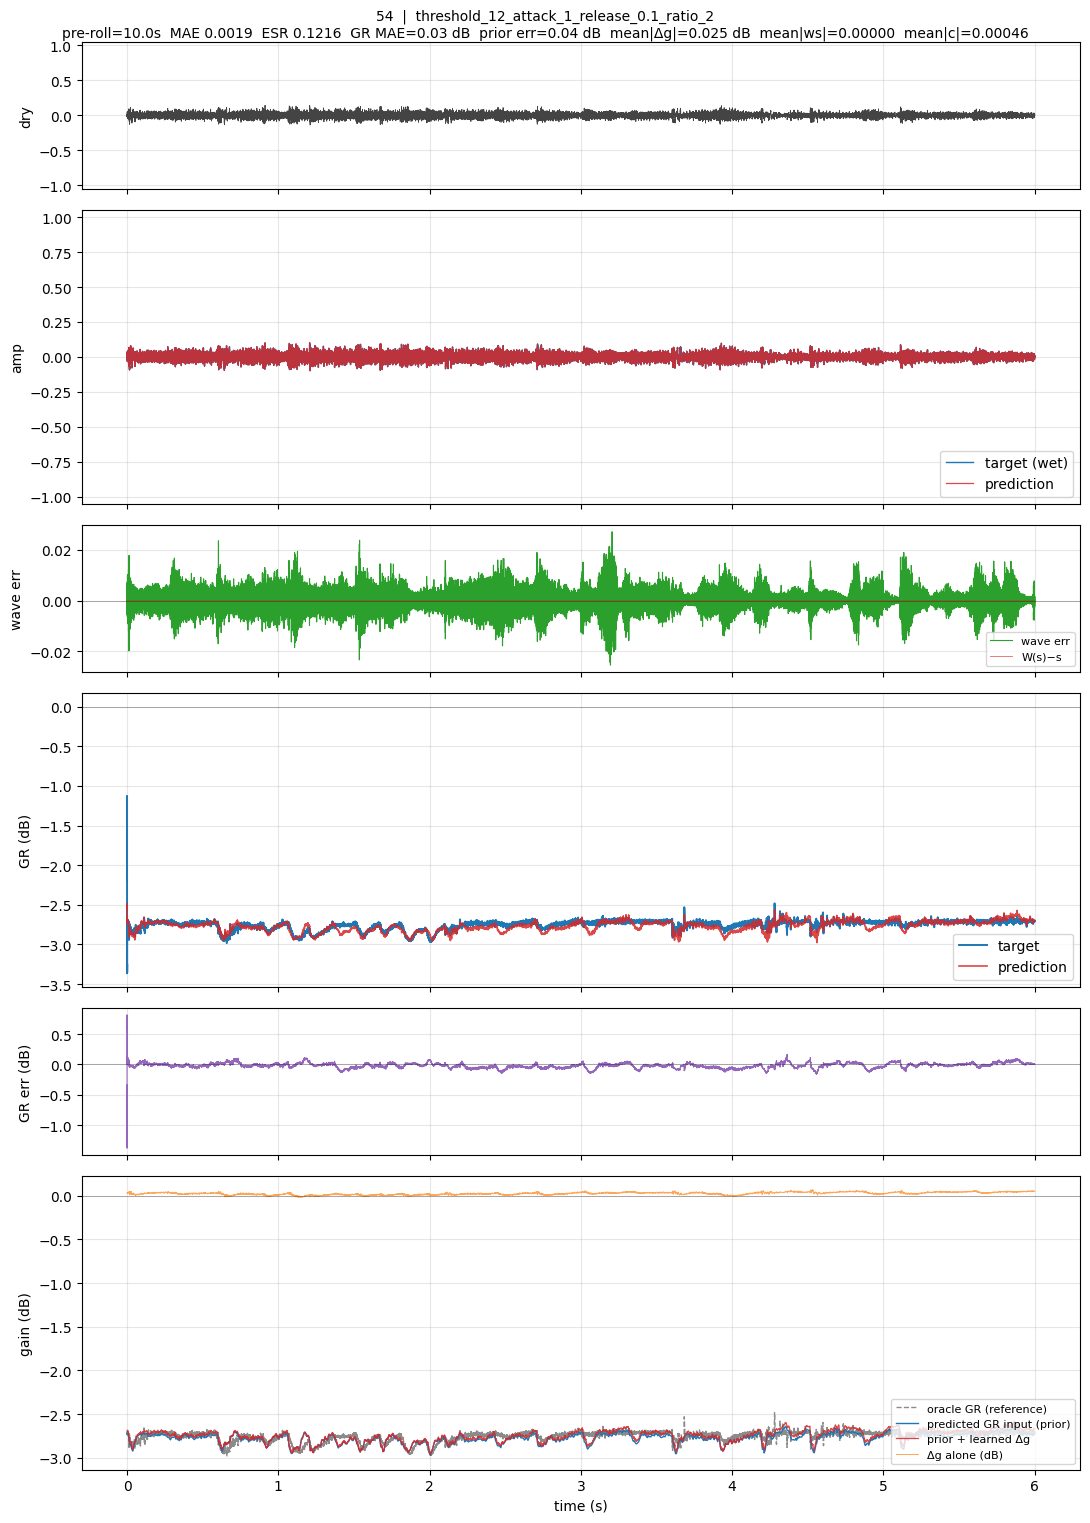

In [12]:
# Single prediction preview — held-out test pair (unseen by both stages)
song, setting = TEST_PAIRS[0]
_ = visualize_prediction(setting=setting, song=song, start_sec=30.0, duration_sec=6.0)


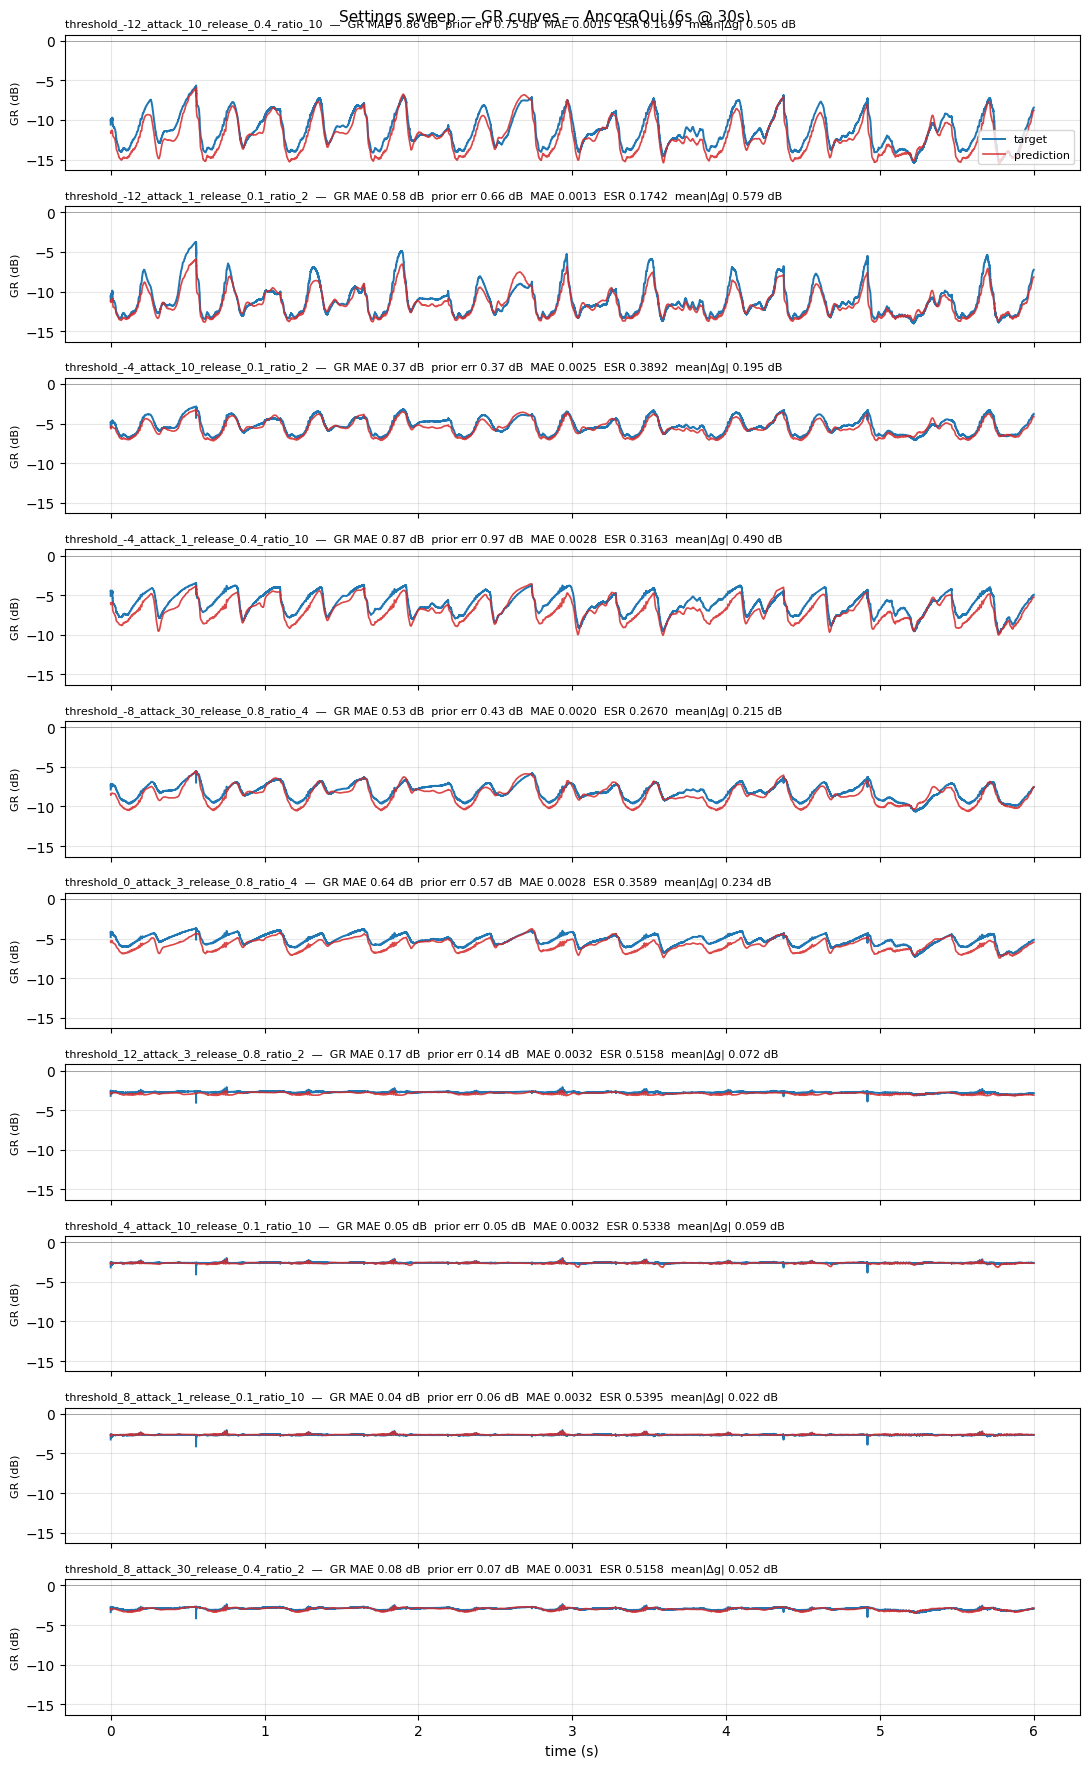

,setting,GR MAE (dB),prior err (dB),MAE,ESR,mean |dg| (dB),mean |ws|,mean |color|
0,threshold_-12_attack_10_release_0.4_ratio_10,0.859007,0.752244,0.001493,0.169871,0.505289,1.787419e-07,0.000247
1,threshold_-12_attack_1_release_0.1_ratio_2,0.581413,0.660107,0.001267,0.174227,0.578574,1.937111e-07,0.000237
2,threshold_-4_attack_10_release_0.1_ratio_2,0.367370,0.366470,0.002501,0.389188,0.195266,3.967346e-07,0.000460
3,threshold_-4_attack_1_release_0.4_ratio_10,0.870967,0.969669,0.002785,0.316290,0.489773,3.346279e-07,0.000440
4,threshold_-8_attack_30_release_0.8_ratio_4,0.528397,0.434196,0.001997,0.266970,0.214987,2.815167e-07,0.000308
5,threshold_0_attack_3_release_0.8_ratio_4,0.637057,0.574785,0.002826,0.358923,0.234292,3.905832e-07,0.000473
6,threshold_12_attack_3_release_0.8_ratio_2,0.169166,0.138001,0.003195,0.515802,0.072022,5.624239e-07,0.000675
7,threshold_4_attack_10_release_0.1_ratio_10,0.053968,0.053177,0.003188,0.533843,0.058638,5.793834e-07,0.000735
8,threshold_8_attack_1_release_0.1_ratio_10,0.041074,0.060878,0.003179,0.539528,0.022319,5.838059e-07,0.000715
9,threshold_8_attack_30_release_0.4_ratio_2,0.080107,0.069925,0.003082,0.515814,0.052277,5.546538e-07,0.000675


In [ ]:
# Settings sweep: validation song through all its settings
sweep_segs, sweep_df = settings_sweep(start_sec=60.0, duration_sec=3.0)


In [14]:
# ── 6b. Metric engine (byte-identical to 06_output/eval_lstm_gain_prior_ws.ipynb) ──
#
# The canonical 9-column table so this model drops straight into the cross-model
# comparison. Every moving-average envelope uses an O(N) cumsum window; the FFT
# metrics reimplement auraloss MultiResolutionSTFTLoss and src.losses.{M_SF, EDC},
# batched. MR-STFT and ESR are verified below against nablafx.evaluation (auraloss)
# to <1e-3 / <1e-4.

from scipy.signal import bilinear, lfilter

EPS = 1e-10

# Multi-resolution window / FFT sets (identical to the diffssl_tvc engine)
MR_STE_WINDOWS   = (256, 1024, 4096)                     # short-time energy (envelope shape)
MR_NRMSE_WINDOWS = (512, 1024, 2048)                     # == src.losses.multi_resolution_nrmse
STFT_SIZES       = (512, 1024, 2048)                     # spectral-flux resolutions
_MRSTFT_RES      = [(1024, 120, 600), (2048, 240, 1200), (512, 50, 240)]   # auraloss defaults

# Final metric columns: GR-stage | colour-stage | standard
METRIC_COLS = [
    "GR MAE (dB)", "MR-STE",                             # GR stage
    "MR-STFT", "ESR (A-wt)",                             # colour stage (auraloss MR-STFT + A-weighted ESR)
    "MAE (L1)", "MSE (L2)", "EDC", "M_NRMSE", "M_SF",    # standard
]


# ── moving-average envelopes (cumsum: O(N), window-independent) ──
def _moving_meansq(x_sq, W, centered):
    """Sliding mean of x**2 via prefix sums. centered=symmetric, else causal (trailing)."""
    n = x_sq.shape[-1]
    c = np.empty(n + 1); c[0] = 0.0; np.cumsum(x_sq, out=c[1:])
    i = np.arange(n)
    if centered:
        lo = i - (W // 2); hi = lo + W
    else:                                                # causal == src.dsp_torch.gain_reduction_db
        hi = i + 1; lo = hi - W
    lo = np.clip(lo, 0, n); hi = np.clip(hi, 0, n)
    return (c[hi] - c[lo]) / np.maximum(hi - lo, 1)

def _to_db(x):       return 20.0 * np.log10(np.maximum(x, EPS))
def _esr(pred, tgt): return float(np.sum((tgt - pred) ** 2) / (np.sum(tgt * tgt) + 1e-8))

# A-weighting IIR (analog prototype -> bilinear) for the A-weighted ESR
def _a_weighting_ba(fs):
    f1, f2, f3, f4 = 20.598997, 107.65265, 737.86223, 12194.217
    A1000 = 1.9997
    nums = [(2 * np.pi * f4) ** 2 * 10 ** (A1000 / 20.0), 0, 0, 0, 0]
    dens = np.polymul([1, 4 * np.pi * f4, (2 * np.pi * f4) ** 2],
                      [1, 4 * np.pi * f1, (2 * np.pi * f1) ** 2])
    dens = np.polymul(np.polymul(dens, [1, 2 * np.pi * f3]), [1, 2 * np.pi * f2])
    return bilinear(nums, dens, fs)
AW_B, AW_A = _a_weighting_ba(SR)


def reference_gr_db(dry, wet, W=RMS_WIN):
    """Reference GR trajectory = causal RMS GR (matches src.dsp_torch.gain_reduction_db)."""
    return (_to_db(np.sqrt(_moving_meansq(wet * wet, W, centered=False)))
            - _to_db(np.sqrt(_moving_meansq(dry * dry, W, centered=False))))


# ── GR-stage / envelope metrics ──
def mr_ste(pred, wet, windows=MR_STE_WINDOWS):
    """Multi-resolution short-time energy distance (envelope shape; Wright & Valimaki)."""
    pe, we = pred * pred, wet * wet
    total = 0.0
    for W in windows:
        ep = _moving_meansq(pe, W, centered=True)
        et = _moving_meansq(we, W, centered=True)
        total += np.sum(np.abs(ep - et)) / (np.sum(np.abs(et)) + 1e-8)
    return float(total / len(windows))

def mr_nrmse(pred, wet, windows=MR_NRMSE_WINDOWS):
    """Mean normalised RMS-envelope error (== src.losses.multi_resolution_nrmse, cumsum-fast)."""
    total = 0.0
    for W in windows:
        rp = np.sqrt(_moving_meansq(pred * pred, W, centered=False))
        rt = np.sqrt(_moving_meansq(wet * wet, W, centered=False))
        total += np.sqrt(np.mean((rt - rp) ** 2)) / (np.sqrt(np.mean(rt * rt)) + 1e-8)
    return float(total / len(windows))


# ── colour-stage + standard FFT metrics ──
_HANN = {}
def _win(n):
    if n not in _HANN:
        _HANN[n] = torch.hann_window(n)
    return _HANN[n]

def _stft_mag_pow(x2d, n_fft, hop, win):
    """auraloss-style magnitude = sqrt(clamp(re^2 + im^2, 1e-8))."""
    st = torch.stft(x2d, n_fft=n_fft, hop_length=hop, win_length=win,
                    window=_win(win), return_complex=True)
    return torch.sqrt(torch.clamp(st.real ** 2 + st.imag ** 2, min=1e-8))

def _stft_mag_fft(x2d, n_fft):
    """src.losses-style magnitude (hop = n_fft // 4, hann(n_fft))."""
    return torch.stft(x2d, n_fft=n_fft, hop_length=n_fft // 4,
                      window=_win(n_fft), return_complex=True).abs()

@torch.no_grad()
def fft_metrics(pred1d: torch.Tensor, wet1d: torch.Tensor) -> dict:
    """auraloss MR-STFT + src.losses {M_SF, EDC} for one (pred, wet) pair."""
    P1, T1 = pred1d.unsqueeze(0), wet1d.unsqueeze(0)
    out = {}

    # MR-STFT (auraloss default = spectral-convergence + log-magnitude, mean over 3 resolutions)
    acc = 0.0
    for n_fft, hop, win in _MRSTFT_RES:
        P = _stft_mag_pow(P1, n_fft, hop, win)[0]
        T = _stft_mag_pow(T1, n_fft, hop, win)[0]
        sc = torch.linalg.norm(T - P) / torch.linalg.norm(T)
        lm = (torch.log(P) - torch.log(T)).abs().mean()
        acc += float(sc + lm)
    out["MR-STFT"] = acc / len(_MRSTFT_RES)

    # spectral-flux (M_SF) over (512, 1024, 2048)
    sf = 0.0
    for n_fft in STFT_SIZES:
        P = _stft_mag_fft(P1, n_fft)[0]
        T = _stft_mag_fft(T1, n_fft)[0]
        pf, tf = torch.diff(P, dim=-1), torch.diff(T, dim=-1)
        sf += float((tf - pf).abs().mean() / (tf.abs().mean() + 1e-8))
    out["M_SF"] = sf / len(STFT_SIZES)

    # EDC (energy-decay-curve error, dB)
    pe = torch.flip(torch.cumsum(torch.flip(P1 ** 2, dims=(-1,)), dim=-1), dims=(-1,))
    te = torch.flip(torch.cumsum(torch.flip(T1 ** 2, dims=(-1,)), dim=-1), dims=(-1,))
    pe = pe / (pe[..., :1] + 1e-8); te = te / (te[..., :1] + 1e-8)
    out["EDC"] = float((10 * torch.log10(te.clamp(min=1e-8))
                        - 10 * torch.log10(pe.clamp(min=1e-8))).abs().mean())
    return out


def chunk_metrics(dry: np.ndarray, pred: np.ndarray, wet: np.ndarray) -> dict:
    """The 9 metric columns for one (dry, pred, wet) chunk (float64 1-D arrays).

    GR MAE compares the prediction's causal-RMS GR against the reference RMS
    GR(dry, wet), both clamped to [GR_DB_MIN, GR_DB_MAX]. FFT metrics run in float32.
    """
    gr_tgt  = np.clip(reference_gr_db(dry, wet),  GR_DB_MIN, GR_DB_MAX)
    gr_pred = np.clip(reference_gr_db(dry, pred), GR_DB_MIN, GR_DB_MAX)
    row = {
        "GR MAE (dB)": float(np.mean(np.abs(gr_pred - gr_tgt))),
        "MR-STE":      mr_ste(pred, wet),
        "ESR (A-wt)":  _esr(lfilter(AW_B, AW_A, pred), lfilter(AW_B, AW_A, wet)),
        "MAE (L1)":    float(np.mean(np.abs(pred - wet))),
        "MSE (L2)":    float(np.mean((pred - wet) ** 2)),
        "M_NRMSE":     mr_nrmse(pred, wet),
    }
    row.update(fft_metrics(torch.from_numpy(pred).float(),
                           torch.from_numpy(wet).float()))
    return row


# ── verify MR-STFT / ESR against nablafx.evaluation (auraloss) ──
try:
    from nablafx.evaluation import get_function
    _g = torch.Generator().manual_seed(0)
    _p = torch.randn(SR, generator=_g); _t = torch.randn(SR, generator=_g)
    _nab_mrstft, _nab_esr = get_function("mrstft_loss"), get_function("esr_loss")
    _pt, _tt = _p.view(1, 1, -1), _t.view(1, 1, -1)
    _fm = fft_metrics(_p, _t)
    _d_mrstft = abs(float(_nab_mrstft(_pt, _tt)) - _fm["MR-STFT"])
    _d_esr = abs(float(_nab_esr(_pt, _tt)) - _esr(_p.double().numpy(), _t.double().numpy()))
    assert _d_mrstft < 1e-3, _d_mrstft
    assert _d_esr < 1e-4, _d_esr
    print(f"nablafx.evaluation verified — MR-STFT Δ={_d_mrstft:.2e}, ESR Δ={_d_esr:.2e}")
except Exception as e:
    print(f"nablafx verification skipped: {e}")

print(f"Metric engine registered — {len(METRIC_COLS)} columns: {METRIC_COLS}")

nablafx.evaluation verified — MR-STFT Δ=0.00e+00, ESR Δ=5.61e-08
Metric engine registered — 9 columns: ['GR MAE (dB)', 'MR-STE', 'MR-STFT', 'ESR (A-wt)', 'MAE (L1)', 'MSE (L2)', 'EDC', 'M_NRMSE', 'M_SF']


In [15]:
# ── 7. Audio metrics on the VALIDATION split (TRUE stateful streaming) ──
# Streams each (song, setting) validation pair whole-song in NON-overlapping
# chunks with all internal LSTM states carried across chunks (matching TBPTT
# training): the main LSTM + the tvcond generator. reset_states() once per
# pair, detach_states() between chunks. The raw dry, the 4 static knobs, and
# the PREDICTED GR curve (sliced from the cached full-song prediction — the
# deployment condition) are fed for each chunk. Chunk length is snapped to a
# multiple of the tvcond block (128). Each chunk is scored with the ported
# metric engine (chunk_metrics) — the SAME 9-column table as the oracle eval,
# results duration-weighted, so oracle-vs-this is a clean column-by-column gap.

MAX_EVAL_PAIRS: int | None = None    # small int for a smoke test
STREAM_CHUNK_SEC = 10.0
SAVE_CHUNK_METRICS = False
MIN_METRIC_FRAMES = max(STFT_SIZES)  # skip sub-FFT tail chunks (torch.stft needs >= n_fft)

sr = SR
_BLOCK = int(HP["model"].get("cond_block_size", 128))
# snap chunk length to a whole number of conditioning blocks
chunk_samples = max(_BLOCK, (int(round(STREAM_CHUNK_SEC * sr)) // _BLOCK) * _BLOCK)


@torch.no_grad()
def stream_pair_metrics(song: str, setting: str) -> list[dict]:
    # Stateful pass over a whole (song, setting) pair; per-chunk metric rows.
    # Serves BOTH splits: pair_paths falls back to test_ground_truth for the
    # external test pairs, and the GR source is always the predicted cache.
    dry_path, wet_path = pair_paths(setting, song)
    total = _pair_num_frames(dry_path, wet_path, sr)
    gr_full = predicted_gr_full(song, setting)
    params = _params_for(setting)

    MODEL.reset_states()
    rows = []
    for ci, o in enumerate(range(0, total, chunk_samples), start=1):
        stop = min(o + chunk_samples, total)
        dry, wet = _read_dry_wet_segment(dry_path, wet_path, o, stop, sr)
        gr = gr_full[..., o:stop]
        n = min(dry.shape[-1], gr.shape[-1], wet.shape[-1])
        if n == 0:
            break
        dry, gr, wet = dry[..., :n], gr[..., :n], wet[..., :n]

        pred = MODEL(dry.unsqueeze(0).to(DEVICE), gr.unsqueeze(0).to(DEVICE), params)
        MODEL.detach_states()
        if n < MIN_METRIC_FRAMES:                       # too short for the largest STFT
            continue

        # float64 1-D arrays for the ported metric engine (FFT metrics run in float32).
        d = dry.squeeze(0).double().cpu().numpy()
        w = wet.squeeze(0).double().cpu().numpy()
        p = pred.squeeze().double().cpu().numpy()
        rows.append({"Chunk": ci, "Start (s)": o / sr, "Duration (s)": n / sr, "Frames": n,
                     **chunk_metrics(d, p, w)})
    return rows


val_pairs = VAL_PAIRS if MAX_EVAL_PAIRS is None else VAL_PAIRS[:MAX_EVAL_PAIRS]
chunk_rows, pair_rows = [], []
for i, (song, setting) in enumerate(val_pairs, start=1):
    print(f"[validation {i}/{len(val_pairs)}] {song} / {setting}")
    rows = stream_pair_metrics(song, setting)
    chunk_rows += [{"Song": song, "Setting": setting, **r} for r in rows]
    pair_rows.append({
        "Split": "validation", "Song": song, "Setting": setting,
        "Duration (s)": sum(r["Frames"] for r in rows) / sr,
        **_weighted_average_metric_rows(rows, METRIC_COLS),
    })
    gc.collect()

total_frames = sum(r["Frames"] for r in chunk_rows)
split_row = {
    "Split": "validation", "Pairs": len(val_pairs), "Chunks": len(chunk_rows),
    "Duration (s)": total_frames / sr,
    **_weighted_average_metric_rows(chunk_rows, METRIC_COLS),
}

pair_metrics_df = pd.DataFrame(pair_rows)
audio_metrics_df = pd.DataFrame([split_row])
pair_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_validation_pairs.csv", index=False)
audio_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_validation.csv", index=False)
if SAVE_CHUNK_METRICS:
    pd.DataFrame(chunk_rows).to_csv(
        Path(RUN_DIR) / "eval_audio_metrics_validation_chunks.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics_validation(.csv, _pairs.csv)")

display(pair_metrics_df)
display(audio_metrics_df)


[validation 1/10] AncoraQui / threshold_-12_attack_10_release_0.4_ratio_10
[validation 2/10] AncoraQui / threshold_-12_attack_1_release_0.1_ratio_2
[validation 3/10] AncoraQui / threshold_-4_attack_10_release_0.1_ratio_2
[validation 4/10] AncoraQui / threshold_-4_attack_1_release_0.4_ratio_10
[validation 5/10] AncoraQui / threshold_-8_attack_30_release_0.8_ratio_4
[validation 6/10] AncoraQui / threshold_0_attack_3_release_0.8_ratio_4
[validation 7/10] AncoraQui / threshold_12_attack_3_release_0.8_ratio_2
[validation 8/10] AncoraQui / threshold_4_attack_10_release_0.1_ratio_10
[validation 9/10] AncoraQui / threshold_8_attack_1_release_0.1_ratio_10
[validation 10/10] AncoraQui / threshold_8_attack_30_release_0.4_ratio_2
Saved -> /Volumes/Saola's Drive/AllCode/thesis/data/diffssl_e2e_runs/e2e_predgr_20260705_185738_diffssl_lstm32_ws_predgr/eval_audio_metrics_validation(.csv, _pairs.csv)


,Split,Song,Setting,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,validation,AncoraQui,threshold_-12_attack_10_release_0.4_ratio_10,233.453424,0.583307,0.126550,0.164434,0.095143,0.001077,0.000004,0.244034,0.080998,0.094747
1,validation,AncoraQui,threshold_-12_attack_1_release_0.1_ratio_2,233.453424,0.405436,0.079872,0.126604,0.093493,0.001035,0.000004,0.421492,0.056520,0.075414
2,validation,AncoraQui,threshold_-4_attack_10_release_0.1_ratio_2,233.453424,0.250440,0.052083,0.084316,0.093542,0.002074,0.000016,0.230119,0.034255,0.044004
3,validation,AncoraQui,threshold_-4_attack_1_release_0.4_ratio_10,233.453424,0.507608,0.117546,0.161435,0.090647,0.001982,0.000011,0.196215,0.075256,0.089993
4,validation,AncoraQui,threshold_-8_attack_30_release_0.8_ratio_4,233.453424,0.411699,0.088971,0.120744,0.094267,0.001538,0.000008,0.344145,0.057247,0.056393
5,validation,AncoraQui,threshold_0_attack_3_release_0.8_ratio_4,233.453424,0.389573,0.084988,0.120097,0.091431,0.002161,0.000015,0.323376,0.054825,0.056431
6,validation,AncoraQui,threshold_12_attack_3_release_0.8_ratio_2,233.453424,0.120534,0.020958,0.054318,0.091757,0.002863,0.000031,0.237212,0.014608,0.020672
7,validation,AncoraQui,threshold_4_attack_10_release_0.1_ratio_10,233.453424,0.079296,0.014646,0.049730,0.091474,0.002962,0.000033,0.198772,0.011845,0.021130
8,validation,AncoraQui,threshold_8_attack_1_release_0.1_ratio_10,233.453424,0.076813,0.012290,0.047347,0.092897,0.002981,0.000034,0.292256,0.010157,0.015261
9,validation,AncoraQui,threshold_8_attack_30_release_0.4_ratio_2,233.453424,0.096111,0.016936,0.050002,0.092021,0.002795,0.000030,0.233138,0.012218,0.018892


,Split,Pairs,Chunks,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,validation,10,240,2334.53424,0.292082,0.061484,0.097903,0.092667,0.002147,0.000019,0.272076,0.040793,0.049294


## Held-out TEST set (`test_ground_truth`)

Final generalisation check on the **external held-out test set** in
`Diff-SSL-G-Comp/test_ground_truth/` — 5 `(song, setting)` pairs whose songs
*and* compressor settings were never seen during training, **by either stage**
(the training notebook asserts the GR predictor was trained under the same
split). Under the v2 policy these ARE `SPLIT.test_pair_keys`, so this is the
run's canonical test set — and because the GR input is predicted from dry +
knobs only, this is the honest deployable number to put next to the oracle
run's test table (upper bound) and the from-scratch SOTA `LSTM32TVC`.

Two cells:

- **8a — inventory.** Discovers the `(song, setting)` pairs under
  `test_ground_truth/`, asserts they equal the manifest's test keys, and makes
  sure the predicted GR curves exist in the cache (no-op if 5d ran).
- **8b — metrics.** Scores the test set with the **exact same** stateful
  whole-song streaming function and canonical 9-column engine as the
  validation cell (`stream_pair_metrics` resolves the wet path and the
  predicted curve identically for both splits). Results are written to
  `eval_audio_metrics_test(.csv, _pairs.csv)` alongside the validation CSVs.


In [16]:
# ── 8a. Held-out test pairs — inventory + predicted curves ────────────

TEST_GT_DIR = os.path.join(DATA_ROOT, "test_ground_truth")


def discover_test_pairs(test_gt_dir: str = TEST_GT_DIR) -> list[tuple[str, str]]:
    # (song, setting) pairs under test_ground_truth that have a dry match.
    dry_dir = os.path.join(DATA_ROOT, "processed_normalized")
    pairs, missing = [], []
    for setting in sorted(os.listdir(test_gt_dir)):
        sdir = os.path.join(test_gt_dir, setting)
        if not os.path.isdir(sdir) or setting.startswith("."):
            continue
        for wet in sorted(glob.glob(os.path.join(sdir, "*-exported.wav"))):
            song = os.path.basename(wet).replace("-exported.wav", "")
            dry = os.path.join(dry_dir, f"{song}_UnmasteredWAV.wav")
            (pairs if os.path.isfile(dry) else missing).append((song, setting))
    if missing:
        print(f"[warning] {len(missing)} test wet files have no dry match (skipped): {missing}")
    return pairs


NEW_TEST_PAIRS = discover_test_pairs()
print(f"Held-out test pairs (test_ground_truth): {len(NEW_TEST_PAIRS)}")

# v2 policy: the on-disk inventory must equal the manifest's test keys — the
# same set the GR predictor's split was asserted against during training.
assert {f"{song}::{setting}" for song, setting in NEW_TEST_PAIRS} == set(SPLIT.test_pair_keys), (
    "test_ground_truth inventory drifted from the run's split manifest")

_ = ensure_predicted_gr(NEW_TEST_PAIRS)   # no-op if 5d ran
for song, setting in NEW_TEST_PAIRS:
    p = _pred_gr_path(song, setting)
    assert os.path.isfile(p)
    print(f"  cached {os.path.relpath(p, GR_RUN_DIR)}")


Held-out test pairs (test_ground_truth): 5
  cached pred_gr_view_best-081-41000/gr_curves/threshold_-12_attack_1_release_0.8_ratio_2/IncidenteEnIntag.pt
  cached pred_gr_view_best-081-41000/gr_curves/threshold_-8_attack_3_release_0.4_ratio_4/OralHygiene.pt
  cached pred_gr_view_best-081-41000/gr_curves/threshold_12_attack_1_release_0.1_ratio_2/54.pt
  cached pred_gr_view_best-081-41000/gr_curves/threshold_4_attack_1_release_0.8_ratio_10/SuchFinePeople.pt
  cached pred_gr_view_best-081-41000/gr_curves/threshold_4_attack_30_release_0.8_ratio_10/Convertible.pt


In [17]:
# ── 8b. Audio metrics on the held-out TEST set (test_ground_truth) ────
# Reuses stream_pair_metrics verbatim: same stateful whole-song streaming in
# block-aligned chunks, same 9-column engine, duration-weighted. pair_paths
# resolves the wet audio from test_ground_truth/ and the GR input is the
# predicted cache — songs AND settings unseen by both stages.

test_chunk_rows, test_pair_rows = [], []
for i, (song, setting) in enumerate(NEW_TEST_PAIRS, start=1):
    print(f"[test {i}/{len(NEW_TEST_PAIRS)}] {song} / {setting}")
    rows = stream_pair_metrics(song, setting)
    test_chunk_rows += [{"Song": song, "Setting": setting, **r} for r in rows]
    test_pair_rows.append({
        "Split": "test", "Song": song, "Setting": setting,
        "Duration (s)": sum(r["Frames"] for r in rows) / sr,
        **_weighted_average_metric_rows(rows, METRIC_COLS),
    })
    gc.collect()

test_total_frames = sum(r["Frames"] for r in test_chunk_rows)
test_split_row = {
    "Split": "test", "Pairs": len(NEW_TEST_PAIRS), "Chunks": len(test_chunk_rows),
    "Duration (s)": test_total_frames / sr,
    **_weighted_average_metric_rows(test_chunk_rows, METRIC_COLS),
}

test_pair_metrics_df = pd.DataFrame(test_pair_rows)
test_audio_metrics_df = pd.DataFrame([test_split_row])
test_pair_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_test_pairs.csv", index=False)
test_audio_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_test.csv", index=False)
if SAVE_CHUNK_METRICS:
    pd.DataFrame(test_chunk_rows).to_csv(
        Path(RUN_DIR) / "eval_audio_metrics_test_chunks.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics_test(.csv, _pairs.csv)")

display(test_pair_metrics_df)
display(test_audio_metrics_df)


[test 1/5] IncidenteEnIntag / threshold_-12_attack_1_release_0.8_ratio_2
[test 2/5] OralHygiene / threshold_-8_attack_3_release_0.4_ratio_4
[test 3/5] 54 / threshold_12_attack_1_release_0.1_ratio_2
[test 4/5] SuchFinePeople / threshold_4_attack_1_release_0.8_ratio_10
[test 5/5] Convertible / threshold_4_attack_30_release_0.8_ratio_10
Saved -> /Volumes/Saola's Drive/AllCode/thesis/data/diffssl_e2e_runs/e2e_predgr_20260705_185738_diffssl_lstm32_ws_predgr/eval_audio_metrics_test(.csv, _pairs.csv)


,Split,Song,Setting,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,test,IncidenteEnIntag,threshold_-12_attack_1_release_0.8_ratio_2,183.199637,0.453651,0.095384,0.118098,0.033399,0.000626,7.511854e-07,0.158910,0.057804,0.073666
1,test,OralHygiene,threshold_-8_attack_3_release_0.4_ratio_4,203.499683,0.643790,0.121764,0.216031,0.088065,0.001213,3.663982e-06,0.084065,0.080865,0.097379
2,test,54,threshold_12_attack_1_release_0.1_ratio_2,248.558005,0.201244,0.013756,0.058131,0.029668,0.001836,7.407974e-06,0.575686,0.009018,0.018260
3,test,SuchFinePeople,threshold_4_attack_1_release_0.8_ratio_10,220.241270,1.561178,0.376212,0.355107,0.073433,0.003631,2.705594e-05,0.231729,0.188330,0.185668
4,test,Convertible,threshold_4_attack_30_release_0.8_ratio_10,204.916100,0.175491,0.034370,0.119775,0.048661,0.002336,1.187892e-05,0.084857,0.024302,0.043965


,Split,Pairs,Chunks,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,test,5,109,1060.414694,0.60725,0.127849,0.172385,0.054279,0.001977,0.00001,0.243052,0.07143,0.082752


## 9. GR-source ablations — flipped for the cascade (no training)

The oracle eval asked "what does the (oracle) GR input buy?". Here the model
was **trained on the predicted curve**, so the table flips: `predicted` is the
native operating point (== the split metrics above) and `oracle` is the
counterfactual.

| Variant | GR source | What it measures |
|---|---|---|
| `predicted` | frozen `BlackboxGRLSTM` (dry + knobs) | **native / deployable** — the numbers above |
| `oracle` | `gr_curves/*.pt` (from wet) | perfect prior fed to the predicted-GR-trained model; `predicted → oracle` is the **residual cost of predictor error** that the learned Δg could not correct |
| `const_mean` | per-pair mean of the oracle GR | static gain with the right average — the value of *temporal* GR information |
| `const_0db` | 0 dB everywhere | prior fully disabled: `y = x + corrections` |
| `amp_match_pred` | predicted GR, **model bypassed** | `dry × 10^(ĝr/20)` — the deployable **stage-1-only** baseline (== this model at zero-init); the trained model must beat this everywhere to justify stage 2 |
| `amp_match_oracle` | oracle GR, **model bypassed** | the no-NN oracle multiply — context row shared with the oracle eval |

Reading the table: `amp_match_pred → predicted` is what **training stage 2
added** on top of the raw cascade; `predicted → oracle` is what a **better
predictor** would still buy; comparing `oracle` here against the oracle run's
native rows shows whether training on an imperfect prior hurt the model's use
of a perfect one. All model variants stream the SAME checkpoint with the SAME
9-column engine.

**Simplified run**: only the first 2 validation pairs (`ABLATION_PAIRS`) are
scored — enough to read the variant ordering — and **9c** (`ablation_gr_sweep`)
plots each pair's GR curves per variant, `settings_sweep`-style.


In [18]:
# ── 9a. Run the GR-source ablation (2 val pairs, same ckpt) ───────────
# Streams the SAME GainPriorWSE2ELSTM checkpoint with different GR sources
# through the SAME 9-column metric engine, plus the model-bypassed amp_match
# baselines. No training anywhere. The frozen predictor is already loaded
# (5c) and its curves cached (5d) — no extra predictor pass is needed.

ABLATION_VARIANTS = ["predicted", "oracle", "const_mean", "const_0db",
                     "amp_match_pred", "amp_match_oracle"]
ABLATION_PAIRS = VAL_PAIRS[:2]   # 2 (song, setting) pairs — the simplified ablation set


def _gr_sources_for_pair(song: str, setting: str, upto: int | None = None):
    # variant -> (gr [1, n] dB, bypass_model) for one pair. `upto` truncates to a
    # prefix (used by the 9c plot cell); const_mean always uses the WHOLE-song mean.
    dry_path, wet_path = pair_paths(setting, song)
    total = _pair_num_frames(dry_path, wet_path, sr)
    n = total if upto is None else min(int(upto), total)
    gr_oracle_full = oracle_gr_full(song, setting)[..., :total]
    gr_pred = predicted_gr_full(song, setting)[..., :n]
    gr_oracle = gr_oracle_full[..., :n]
    return {
        "predicted": (gr_pred, False),
        "oracle": (gr_oracle, False),
        "const_mean": (torch.full_like(gr_oracle, float(gr_oracle_full.mean())), False),
        "const_0db": (torch.zeros_like(gr_oracle), False),
        "amp_match_pred": (gr_pred, True),      # model bypassed, predicted prior
        "amp_match_oracle": (gr_oracle, True),  # model bypassed, oracle prior
    }


@torch.no_grad()
def stream_pair_metrics_with_gr(song: str, setting: str, gr_full: torch.Tensor,
                                bypass_model: bool = False) -> list[dict]:
    # stream_pair_metrics (cell 7) with an arbitrary, precomputed GR source.
    # bypass_model=True skips the network entirely: pred = dry x 10^(gr/20)
    # (the amplitude-match baseline, == the zero-init model by construction).
    dry_path, wet_path = pair_paths(setting, song)
    total = _pair_num_frames(dry_path, wet_path, sr)
    params = _params_for(setting)

    MODEL.reset_states()
    rows = []
    for ci, o in enumerate(range(0, total, chunk_samples), start=1):
        stop = min(o + chunk_samples, total)
        dry, wet = _read_dry_wet_segment(dry_path, wet_path, o, stop, sr)
        gr = gr_full[..., o:stop]
        n = min(dry.shape[-1], gr.shape[-1], wet.shape[-1])
        if n == 0:
            break
        dry, gr, wet = dry[..., :n], gr[..., :n], wet[..., :n]

        if bypass_model:
            pred = amplitude_match(dry.unsqueeze(0), gr.unsqueeze(0))
        else:
            pred = MODEL(dry.unsqueeze(0).to(DEVICE), gr.unsqueeze(0).to(DEVICE), params)
            MODEL.detach_states()
        if n < MIN_METRIC_FRAMES:
            continue
        d = dry.squeeze(0).double().cpu().numpy()
        w = wet.squeeze(0).double().cpu().numpy()
        p = pred.squeeze().double().cpu().numpy()
        rows.append({"Chunk": ci, "Frames": n, **chunk_metrics(d, p, w)})
    return rows


abl_chunk_rows = {v: [] for v in ABLATION_VARIANTS}
abl_pair_rows, _pred_gr_maes = [], []

for i, (song, setting) in enumerate(ABLATION_PAIRS, start=1):
    sources = _gr_sources_for_pair(song, setting)
    _gr_hat, _gr_or = sources["predicted"][0], sources["oracle"][0]
    _n = min(_gr_hat.shape[-1], _gr_or.shape[-1])
    _pred_gr_maes.append(float(
        (_gr_hat[..., :_n].clamp(GR_DB_MIN, GR_DB_MAX)
         - _gr_or[..., :_n].clamp(GR_DB_MIN, GR_DB_MAX)).abs().mean()))

    for variant in ABLATION_VARIANTS:
        gr_full, bypass = sources[variant]
        print(f"[{i}/{len(ABLATION_PAIRS)}] {song} / {setting} — {variant}")
        rows = stream_pair_metrics_with_gr(song, setting, gr_full, bypass_model=bypass)
        abl_chunk_rows[variant] += rows
        abl_pair_rows.append({
            "Variant": variant, "Song": song, "Setting": setting,
            "Frames": sum(r["Frames"] for r in rows),
            **_weighted_average_metric_rows(rows, METRIC_COLS),
        })
    gc.collect()

print(f"\npredictor GR MAE vs oracle over {len(_pred_gr_maes)} pairs: "
      f"{np.mean(_pred_gr_maes):.3f} dB")

abl_split_df = pd.DataFrame([
    {"Variant": v, "Pairs": len(ABLATION_PAIRS),
     "Duration (s)": sum(r["Frames"] for r in abl_chunk_rows[v]) / sr,
     **_weighted_average_metric_rows(abl_chunk_rows[v], METRIC_COLS)}
    for v in ABLATION_VARIANTS
])
abl_pair_df = pd.DataFrame(abl_pair_rows)

abl_pair_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_gr_ablation_pairs.csv", index=False)
abl_split_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_gr_ablation.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics_gr_ablation(.csv, _pairs.csv)")

# Context rows for reading the table: the oracle WS run's val/ablation CSVs in
# diffssl_gain_prior_runs/ (same pairs, same engine) are the upper-bound twins.
display(abl_split_df)
display(abl_pair_df)


[1/2] AncoraQui / threshold_-12_attack_10_release_0.4_ratio_10 — predicted
[1/2] AncoraQui / threshold_-12_attack_10_release_0.4_ratio_10 — oracle
[1/2] AncoraQui / threshold_-12_attack_10_release_0.4_ratio_10 — const_mean
[1/2] AncoraQui / threshold_-12_attack_10_release_0.4_ratio_10 — const_0db
[1/2] AncoraQui / threshold_-12_attack_10_release_0.4_ratio_10 — amp_match_pred
[1/2] AncoraQui / threshold_-12_attack_10_release_0.4_ratio_10 — amp_match_oracle
[2/2] AncoraQui / threshold_-12_attack_1_release_0.1_ratio_2 — predicted
[2/2] AncoraQui / threshold_-12_attack_1_release_0.1_ratio_2 — oracle
[2/2] AncoraQui / threshold_-12_attack_1_release_0.1_ratio_2 — const_mean
[2/2] AncoraQui / threshold_-12_attack_1_release_0.1_ratio_2 — const_0db
[2/2] AncoraQui / threshold_-12_attack_1_release_0.1_ratio_2 — amp_match_pred
[2/2] AncoraQui / threshold_-12_attack_1_release_0.1_ratio_2 — amp_match_oracle

predictor GR MAE vs oracle over 2 pairs: 0.538 dB
Saved -> /Volumes/Saola's Drive/AllCode/t

,Variant,Pairs,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,predicted,2,466.906848,0.494371,0.103211,0.145519,0.094318,0.001056,0.000004,0.332763,0.068759,0.085081
1,oracle,2,466.909070,0.274936,0.056841,0.096635,0.088710,0.000980,0.000003,0.228140,0.036633,0.063815
2,const_mean,2,466.909070,1.834831,0.354150,0.402767,0.142573,0.001607,0.000006,0.712041,0.199790,0.208775
3,const_0db,2,466.909070,4.999323,2.438279,1.429515,0.773516,0.006203,0.000076,0.342732,0.862998,0.826444
4,amp_match_pred,2,466.906848,0.669081,0.140235,0.195984,0.113294,0.001223,0.000004,0.336078,0.093981,0.140014
5,amp_match_oracle,2,466.909070,0.378762,0.086948,0.147020,0.101995,0.001145,0.000004,0.224141,0.061965,0.115372


,Variant,Song,Setting,Frames,GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,predicted,AncoraQui,threshold_-12_attack_10_release_0.4_ratio_10,10295296,0.583307,0.126550,0.164434,0.095143,0.001077,0.000004,0.244034,0.080998,0.094747
1,oracle,AncoraQui,threshold_-12_attack_10_release_0.4_ratio_10,10295345,0.305342,0.071512,0.106684,0.088570,0.000964,0.000003,0.257410,0.045539,0.069109
2,const_mean,AncoraQui,threshold_-12_attack_10_release_0.4_ratio_10,10295345,2.219851,0.400123,0.471465,0.162513,0.001723,0.000006,0.792205,0.235020,0.249583
3,const_0db,AncoraQui,threshold_-12_attack_10_release_0.4_ratio_10,10295345,5.201310,2.477339,1.465039,0.874031,0.005911,0.000067,0.388095,0.879603,0.841574
4,amp_match_pred,AncoraQui,threshold_-12_attack_10_release_0.4_ratio_10,10295296,0.710605,0.162824,0.209041,0.118262,0.001213,0.000004,0.361429,0.107880,0.139901
5,amp_match_oracle,AncoraQui,threshold_-12_attack_10_release_0.4_ratio_10,10295345,0.402684,0.100162,0.153491,0.105960,0.001112,0.000004,0.234342,0.072573,0.113956
6,predicted,AncoraQui,threshold_-12_attack_1_release_0.1_ratio_2,10295296,0.405436,0.079872,0.126604,0.093493,0.001035,0.000004,0.421492,0.056520,0.075414
7,oracle,AncoraQui,threshold_-12_attack_1_release_0.1_ratio_2,10295345,0.244530,0.042169,0.086586,0.088849,0.000996,0.000003,0.198870,0.027727,0.058521
8,const_mean,AncoraQui,threshold_-12_attack_1_release_0.1_ratio_2,10295345,1.449811,0.308177,0.334069,0.122633,0.001491,0.000005,0.631876,0.164560,0.167966
9,const_0db,AncoraQui,threshold_-12_attack_1_release_0.1_ratio_2,10295345,4.797335,2.399220,1.393992,0.673001,0.006495,0.000085,0.297368,0.846393,0.811315


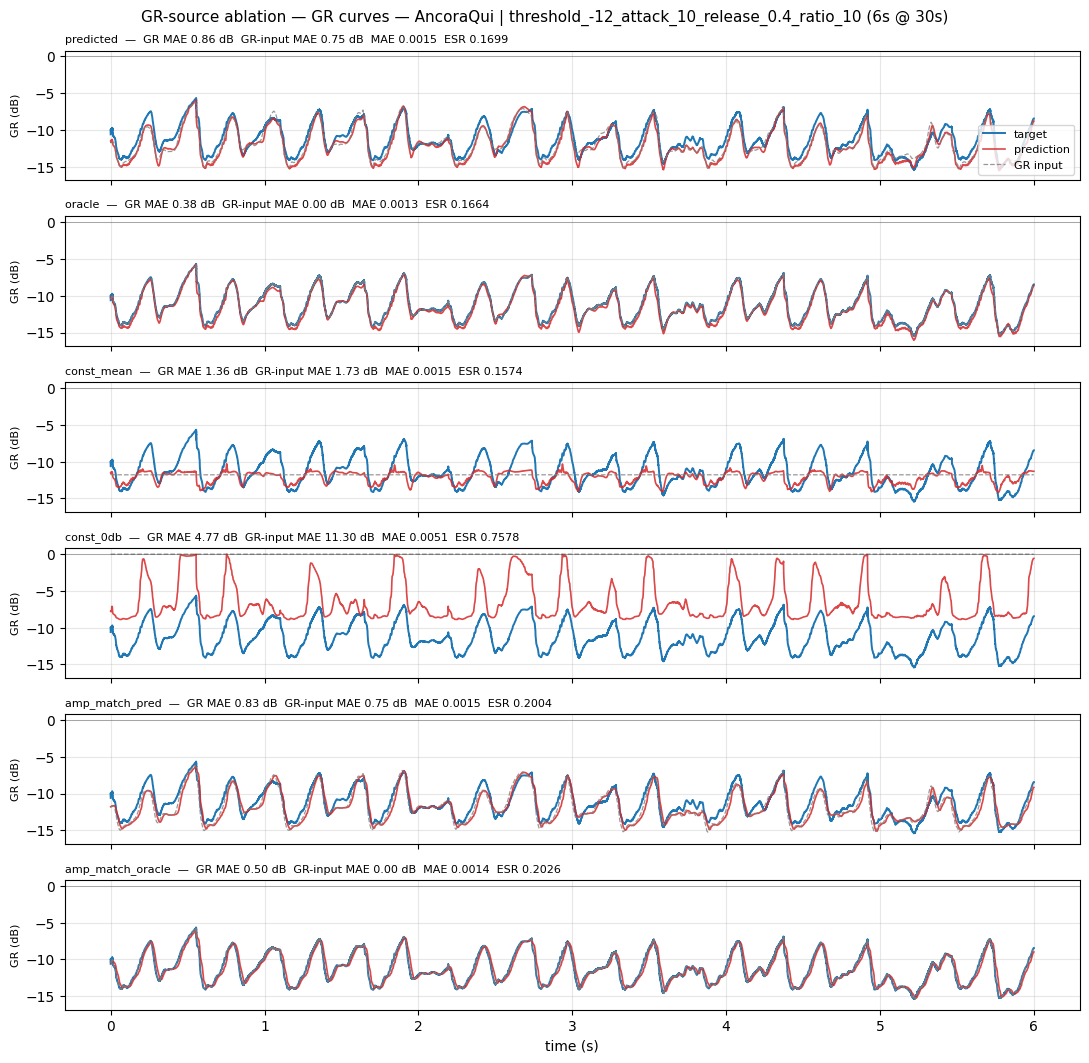

,variant,GR MAE (dB),GR-input MAE (dB),MAE,ESR
0,predicted,0.859007,0.752818,0.001493,0.169871
1,oracle,0.378010,0.000823,0.001266,0.166352
2,const_mean,1.362011,1.732205,0.001547,0.157402
3,const_0db,4.765901,11.303969,0.005149,0.757766
4,amp_match_pred,0.832318,0.752818,0.001547,0.200418
5,amp_match_oracle,0.497768,0.000823,0.001449,0.202587


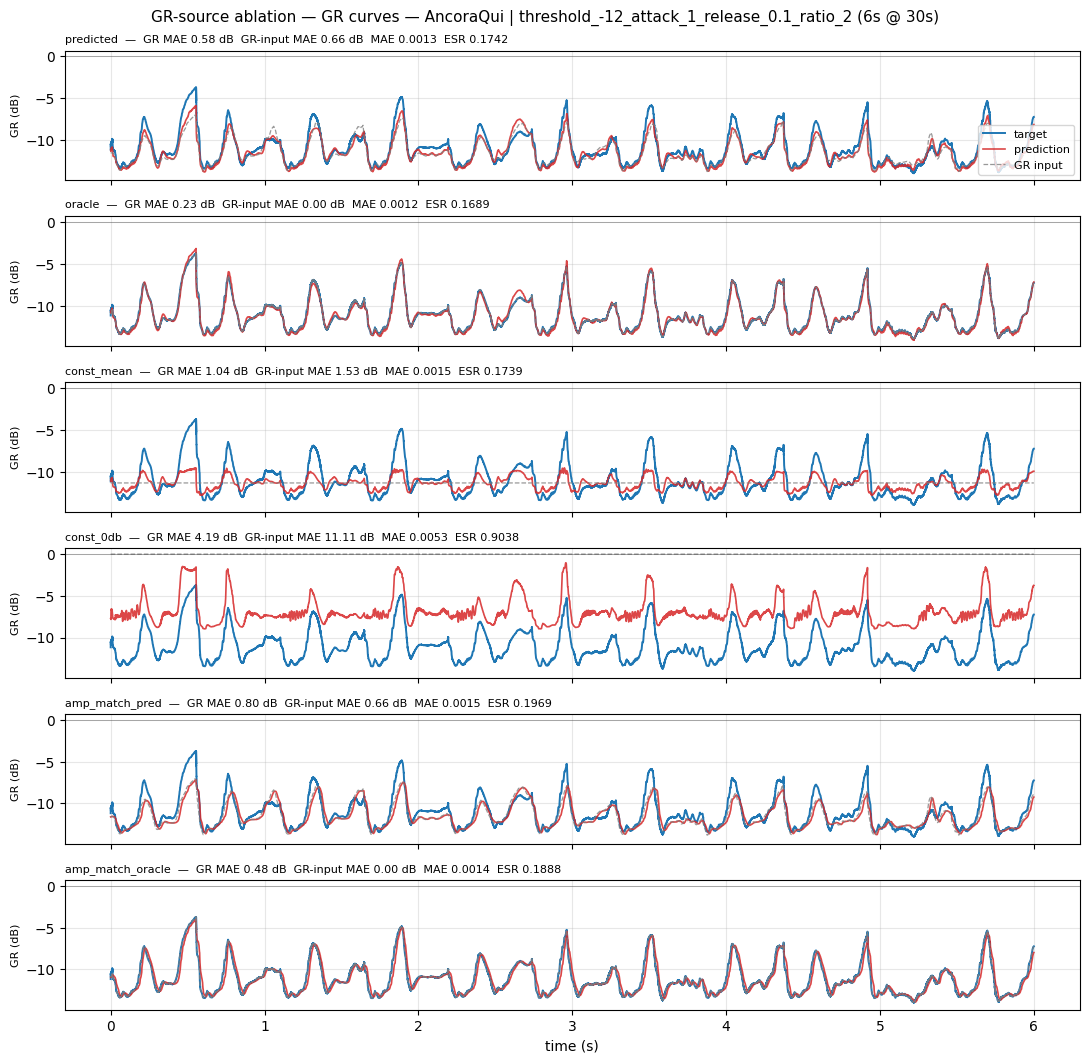

,variant,GR MAE (dB),GR-input MAE (dB),MAE,ESR
0,predicted,0.581413,0.661133,0.001267,0.174227
1,oracle,0.229044,0.001139,0.001199,0.168920
2,const_mean,1.044440,1.534398,0.001479,0.173906
3,const_0db,4.186603,11.111997,0.005277,0.903784
4,amp_match_pred,0.802103,0.661133,0.001463,0.196889
5,amp_match_oracle,0.483062,0.001139,0.001430,0.188759


In [19]:
# ── 9c. Ablation GR curves — settings_sweep-style plot per pair ────────
# For each ablation pair, run the same 6 s @ 30 s segment (10 s pre-roll after
# reset_states — the settings_sweep protocol) once per GR source and plot the
# GR curves: target (from wet) vs prediction (recovered from the variant output)
# vs the GR actually fed to the model (dashed).

@torch.no_grad()
def predict_segment_with_gr(setting, song, gr_full, bypass_model=False,
                            start_sec=30.0, duration_sec=6.0,
                            pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    # predict_wet_segment (cell 6) with an arbitrary, precomputed GR source
    # (gr_full must cover [0, start+duration) samples).
    dry_path, wet_path = pair_paths(setting, song)
    start = int(round(start_sec * sr))
    stop = start + int(round(duration_sec * sr))
    context_start = max(0, start - int(round(pre_roll_sec * sr)))
    offset = start - context_start

    dry_ctx, wet_ctx = _read_dry_wet_segment(dry_path, wet_path, context_start, stop, sr)
    gr_ctx = gr_full[..., context_start:stop]
    n = min(dry_ctx.shape[-1], gr_ctx.shape[-1], wet_ctx.shape[-1])
    dry_ctx, gr_ctx, wet_ctx = dry_ctx[..., :n], gr_ctx[..., :n], wet_ctx[..., :n]

    if bypass_model:
        pred_full = amplitude_match(dry_ctx.unsqueeze(0), gr_ctx.unsqueeze(0))
    else:
        MODEL.reset_states()
        pred_full = MODEL(dry_ctx.unsqueeze(0).to(DEVICE), gr_ctx.unsqueeze(0).to(DEVICE),
                          _params_for(setting))

    seg_len = min(stop - start, pred_full.shape[-1] - offset)
    sl = slice(offset, offset + seg_len)
    pred = pred_full[..., sl].squeeze(0).cpu()
    wet, dry = wet_ctx[..., sl].cpu(), dry_ctx[..., sl].cpu()
    gr_in = np.clip(gr_ctx[..., sl].squeeze().numpy(), GR_DB_MIN, GR_DB_MAX)
    err = (pred - wet).squeeze().numpy()
    gr_true, gr_pred = _gr_from_audio(dry, wet), _gr_from_audio(dry, pred)
    return {
        "song": song, "setting": setting, "time": np.arange(pred.shape[-1]) / sr,
        "gr_in": gr_in, "gr_true": gr_true, "gr_pred": gr_pred,
        "mae": float(np.mean(np.abs(err))),
        "esr": float(esr_metric(wet.unsqueeze(0), pred.unsqueeze(0))),
        "gr_mae_db": float(np.mean(np.abs(gr_pred - gr_true))),
        "gr_in_mae_db": float(np.mean(np.abs(gr_in - gr_true))),
    }


def ablation_gr_sweep(song, setting, start_sec=30.0, duration_sec=6.0,
                      pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    # One (song, setting) pair through every GR source — rows = variants,
    # same layout as settings_sweep.
    stop = int(round((start_sec + duration_sec) * sr))
    sources = _gr_sources_for_pair(song, setting, upto=stop)
    segs = []
    for variant in ABLATION_VARIANTS:
        gr_full, bypass = sources[variant]
        seg = predict_segment_with_gr(setting, song, gr_full, bypass_model=bypass,
                                      start_sec=start_sec, duration_sec=duration_sec,
                                      pre_roll_sec=pre_roll_sec)
        seg["variant"] = variant
        segs.append(seg)

    fig, axes = plt.subplots(len(segs), 1, figsize=(11, 1.8 * len(segs)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, s in zip(axes[:, 0], segs):
        ax.plot(s["time"], s["gr_true"], lw=1.4, color="#1f77b4", label="target")
        ax.plot(s["time"], s["gr_pred"], lw=1.2, color="#d62728", alpha=0.85, label="prediction")
        ax.plot(s["time"], s["gr_in"], lw=0.9, ls="--", color="#7f7f7f", alpha=0.8,
                label="GR input")
        ax.axhline(0, color="k", lw=0.5, alpha=0.4)
        ax.set_ylabel("GR (dB)", fontsize=8)
        ax.set_title(
            f"{s['variant']}  —  GR MAE {s['gr_mae_db']:.2f} dB  "
            f"GR-input MAE {s['gr_in_mae_db']:.2f} dB  "
            f"MAE {s['mae']:.4f}  ESR {s['esr']:.4f}",
            fontsize=8, loc="left",
        )
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc="lower right", fontsize=8)
    axes[-1, 0].set_xlabel("time (s)")
    fig.suptitle(f"GR-source ablation — GR curves — {song} | {setting} "
                 f"({duration_sec:.0f}s @ {start_sec:.0f}s)", fontsize=11)
    plt.tight_layout(); plt.show()

    df = pd.DataFrame([
        {"variant": s["variant"], "GR MAE (dB)": s["gr_mae_db"],
         "GR-input MAE (dB)": s["gr_in_mae_db"], "MAE": s["mae"], "ESR": s["esr"]}
        for s in segs
    ])
    display(df)
    return segs, df


abl_sweeps = {
    (song, setting): ablation_gr_sweep(song, setting, start_sec=30.0, duration_sec=6.0)
    for song, setting in ABLATION_PAIRS
}
